In [2]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from core import *

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
#check upper bound T
N = 50
T = 0.5

params = SystemParams()
params.A_L, params.A_F = -1.0, -1.0
params.B_L, params.B_F = 1.0, 1.0
params.sig_L, params.sig_F = 0.1, 0.1
params.M_true = 1.0
params.lamb_F = 1.0
params.lamb_L = .5
params.Q_L_T = 0.0
params.Q_L, params.Q_F = 0., 1.0
params.R_L, params.R_F = 1.0, 1.0
params.X_L_0, params.X_F_0 = 0.1, 0.1
params.T, params.N = 0.5, 50
params.device = device
params.time_grid = torch.linspace(0, params.T, params.N+1, device=params.device)
params.dt = params.T / params.N

def calculate_upper_bound(params):
    h_grid = compute_h_grid(params)
    h_grid = h_grid.to(device)
    k_grid = compute_k_grid(params)
    h_inf_norm = torch.max(torch.abs(h_grid))
    k_inf_norm = torch.max(torch.abs(k_grid))
    k_1_norm = torch.sum(torch.abs(k_grid)) * params.dt
    q = max(abs(params.Q_L/2 - (params.A_L + h_inf_norm)), ((params.B_F**4/((params.R_F**2)*(params.sig_F**2)))*params.lamb_L + 1)*k_inf_norm)
    beta = max((2/params.R_L)*params.B_L**2 + abs(params.A_L), h_inf_norm, k_inf_norm)
    y_0 = max(params.Q_L_T/2, (params.B_F**4/((params.R_F**2)*(params.sig_F**2)))*params.lamb_L*(k_1_norm + 1))
    print(q, beta, y_0)
    print(torch.sqrt((beta * y_0) / q))
    upperbound = (4*beta*q)**(-0.5) * (torch.pi - 2 * torch.atan(torch.sqrt((beta * y_0) / q)))
    return upperbound.item()

print("Upper bound T:", calculate_upper_bound(params))

tensor(166.3467) tensor(3.2617) tensor(100.0752)
tensor(1.4008)
Upper bound T: 0.026616225019097328


/var/folders/bs/pjtn_x6x0vlg303wglbxqthm0000gn/T/ipykernel_97861/121597069.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net.load_state_dict(torch.load("/Users/daniel

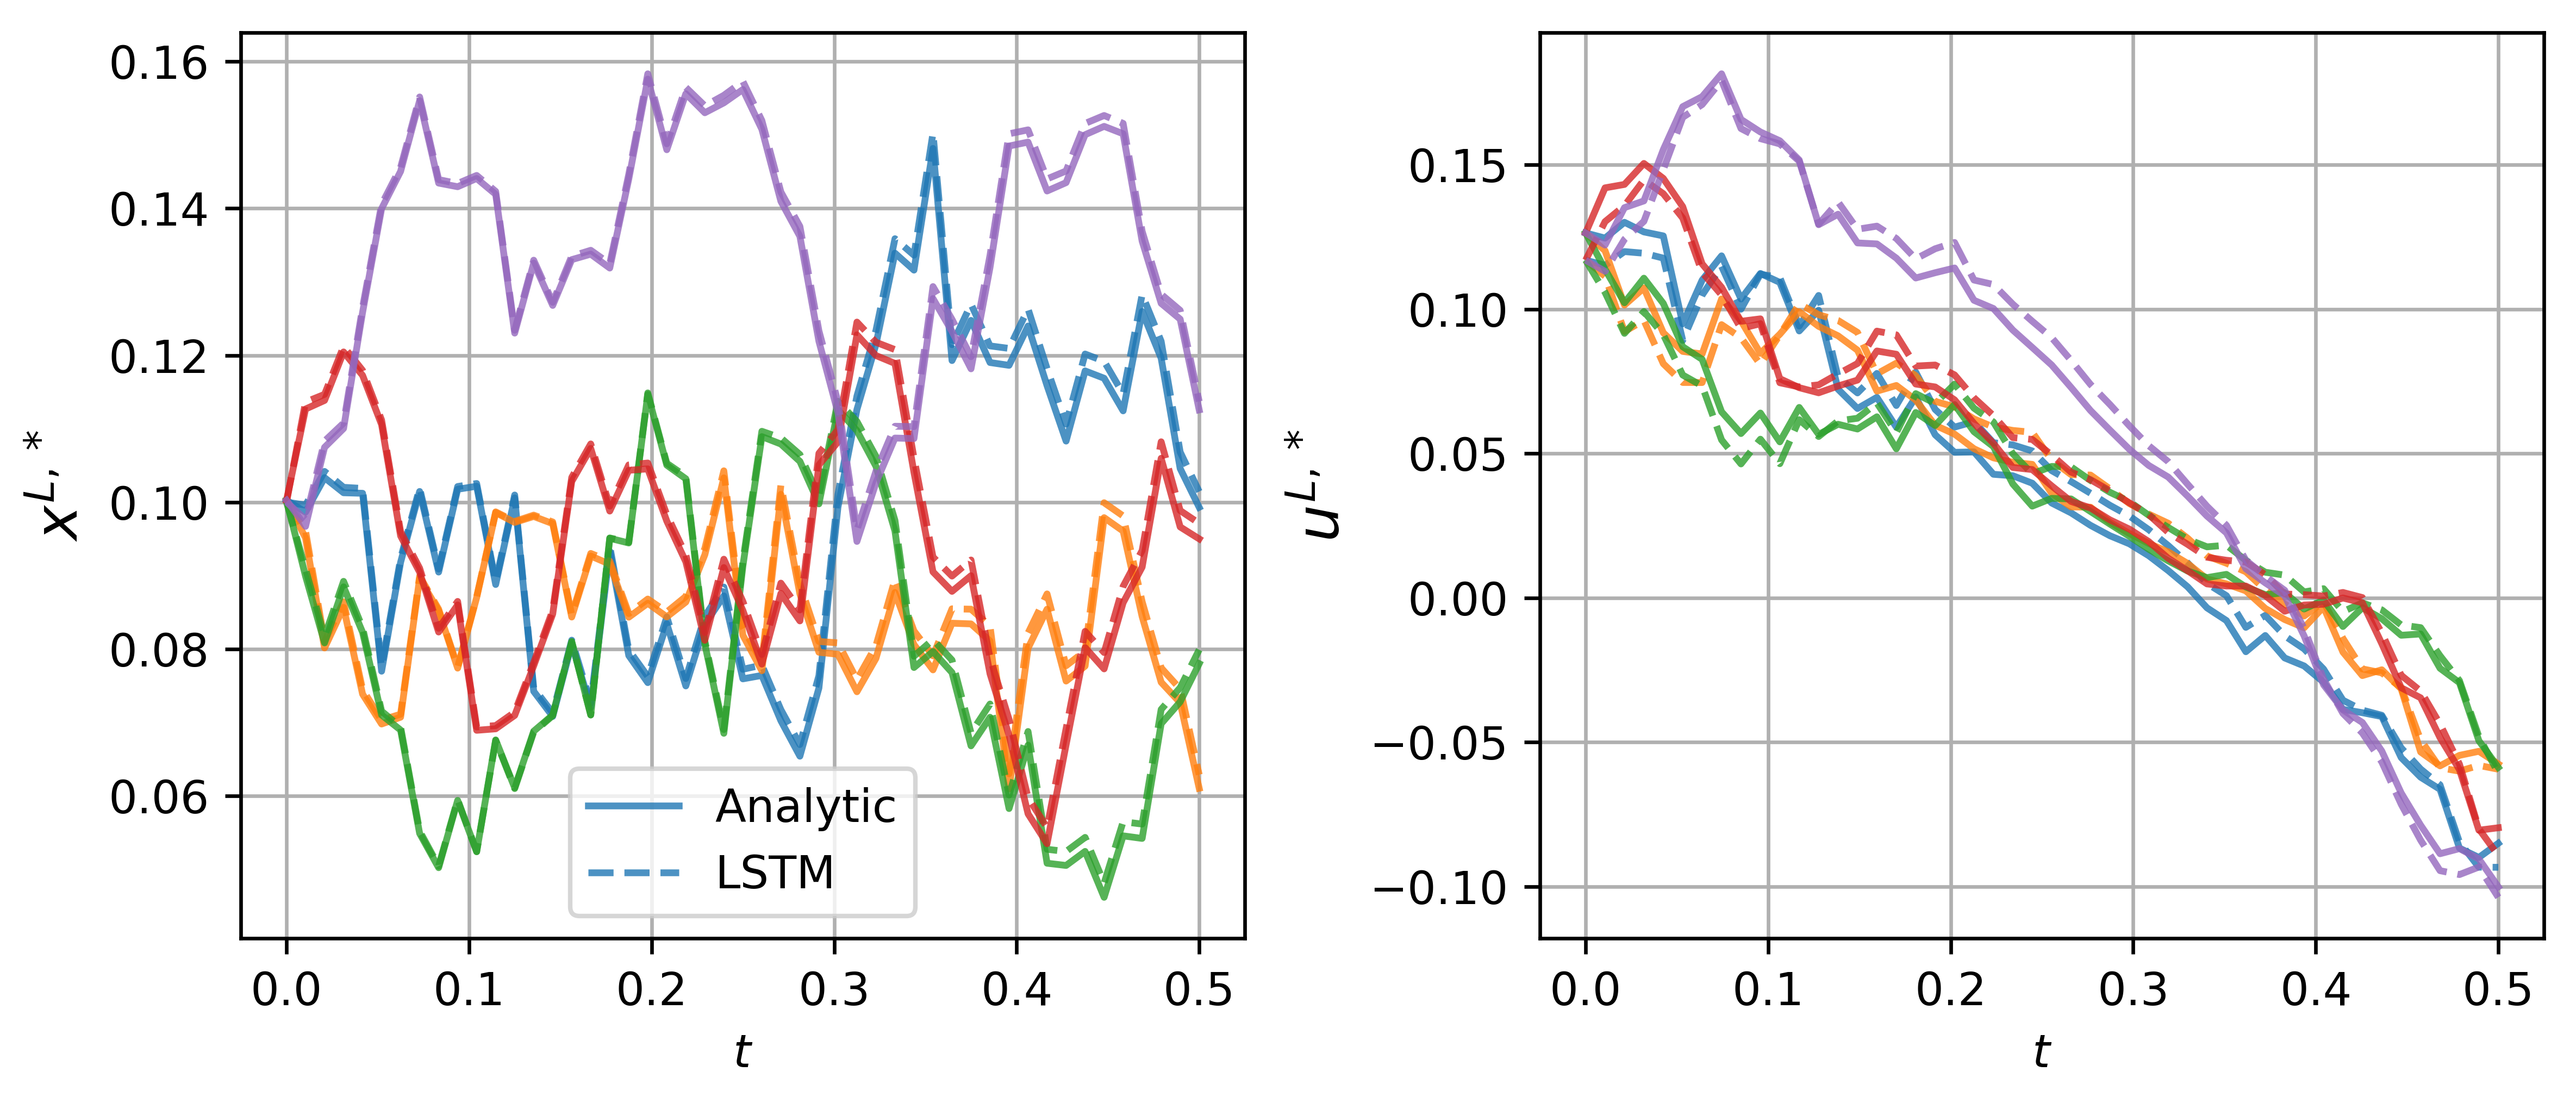

In [3]:
# plot learned vs analytic leader control and state trajectories
T=0.5

def F(x):
    return 0.2 * torch.sin(2*np.pi * x / params.T)
    # return 0*torch.ones_like(x, device=params.device)

params = SystemParams()
params.A_L, params.A_F = -1.0, -1.0
params.B_L, params.B_F = 1.0, 1.0
params.sig_L, params.sig_F = 0.1, 0.1
params.M_true = 1.0
params.lamb_F = 1.0
params.lamb_L = .5
params.Q_L_T = 1.0
params.Q_L, params.Q_F = 1.0, 1.0
params.R_L, params.R_F = 1.0, 1.0
params.X_L_0, params.X_F_0 = 0.1, 0.1
params.T, params.N = T, 50
params.device = device
params.time_grid = torch.linspace(0, params.T, params.N+1, device=params.device)
params.dt = params.T / params.N

leader_analytic = LeaderLBSolver(params, F)

net = DeepLSTMController(hidden=64, num_layers=2)
net.load_state_dict(torch.load("/Users/danielralston/Desktop/Strategic-Inference-Stackleburg-Games/src/runs/designing_communist/loss_-4.777e-03_upd_4563.pt", map_location=device))
net.to(device)
u_NN = make_nn_policy(net, params)

seed_plot = 42
batch_size_plot = 10000   # tune as desired
torch.manual_seed(seed_plot)
X_L_a_batch, U_L_a_batch = leader_analytic.simulate(batch=batch_size_plot, seed=seed_plot)
X_L_a_batch, U_L_a_batch = X_L_a_batch.detach(), U_L_a_batch.detach()
X_L_nn_batch, U_L_nn_batch = simulate_leader(u_NN, params, batch=batch_size_plot, seed=seed_plot)
X_L_nn_batch, U_L_nn_batch = X_L_nn_batch.detach(), U_L_nn_batch.detach()


samples = [i for i in range(1,6)]  

# plt.rcParams.update({
#     "font.size": 8,
#     "font.weight": 550,
#     "axes.titleweight": 575,
#     "axes.labelweight": 575,
#     "axes.titlesize": 12,
#     "axes.labelsize": 10,
#     "xtick.labelsize": 8,
#     "ytick.labelsize": 8,
#     "legend.fontsize": 8,
#     "lines.linewidth": 2.0,
#     "lines.markersize": 5,
#     "hatch.linewidth": 4.0
# })

fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(8, 3.5), dpi=600)

# Left subplot: leader control trajectories
for i, ind in enumerate(samples):
    color = f'C{i}'
    ax1.plot(torch.linspace(0, params.T, U_L_a_batch[ind].shape[0]),
             U_L_a_batch[ind].cpu().numpy(),
             linestyle='-', color=color,
             alpha=0.8,
             label=f'Analytic' if i == 0 else None)
    ax1.plot(torch.linspace(0, params.T, U_L_a_batch[ind].shape[0]),
             U_L_nn_batch[ind].cpu().numpy(),
             linestyle='--', color=color,
             alpha=0.8,
             label=f'LSTM' if i == 0 else None)
# ax1.set_title(f'Controls')
ax1.set_xlabel('$t$', fontsize=10)
ax1.set_ylabel('$u^{L,*}$', fontsize=13)
# ax1.legend(fontsize=10)
ax1.grid(True)

# Right subplot: leader state trajectories
for i, ind in enumerate(samples):
    color = f'C{i}'
    ax2.plot(torch.linspace(0, params.T, X_L_a_batch[ind].shape[0]),
             X_L_a_batch[ind].cpu().numpy(),
             linestyle='-', color=color,
             alpha=0.8,
             label=f'Analytic' if i == 0 else None)
    ax2.plot(torch.linspace(0, params.T, X_L_nn_batch[ind].shape[0]),
             X_L_nn_batch[ind].cpu().numpy(),
             linestyle='--', color=color,
             alpha=0.8,
             label=f'LSTM' if i == 0 else None) 
# ax2.set_title(f'State Trajectories')
ax2.set_xlabel('$t$', fontsize=10)
ax2.set_ylabel('$x^{L,*}$', fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True)
plt.tight_layout()
plt.show()

RuntimeError: expected m1 and m2 to have the same dtype, but got: float != double

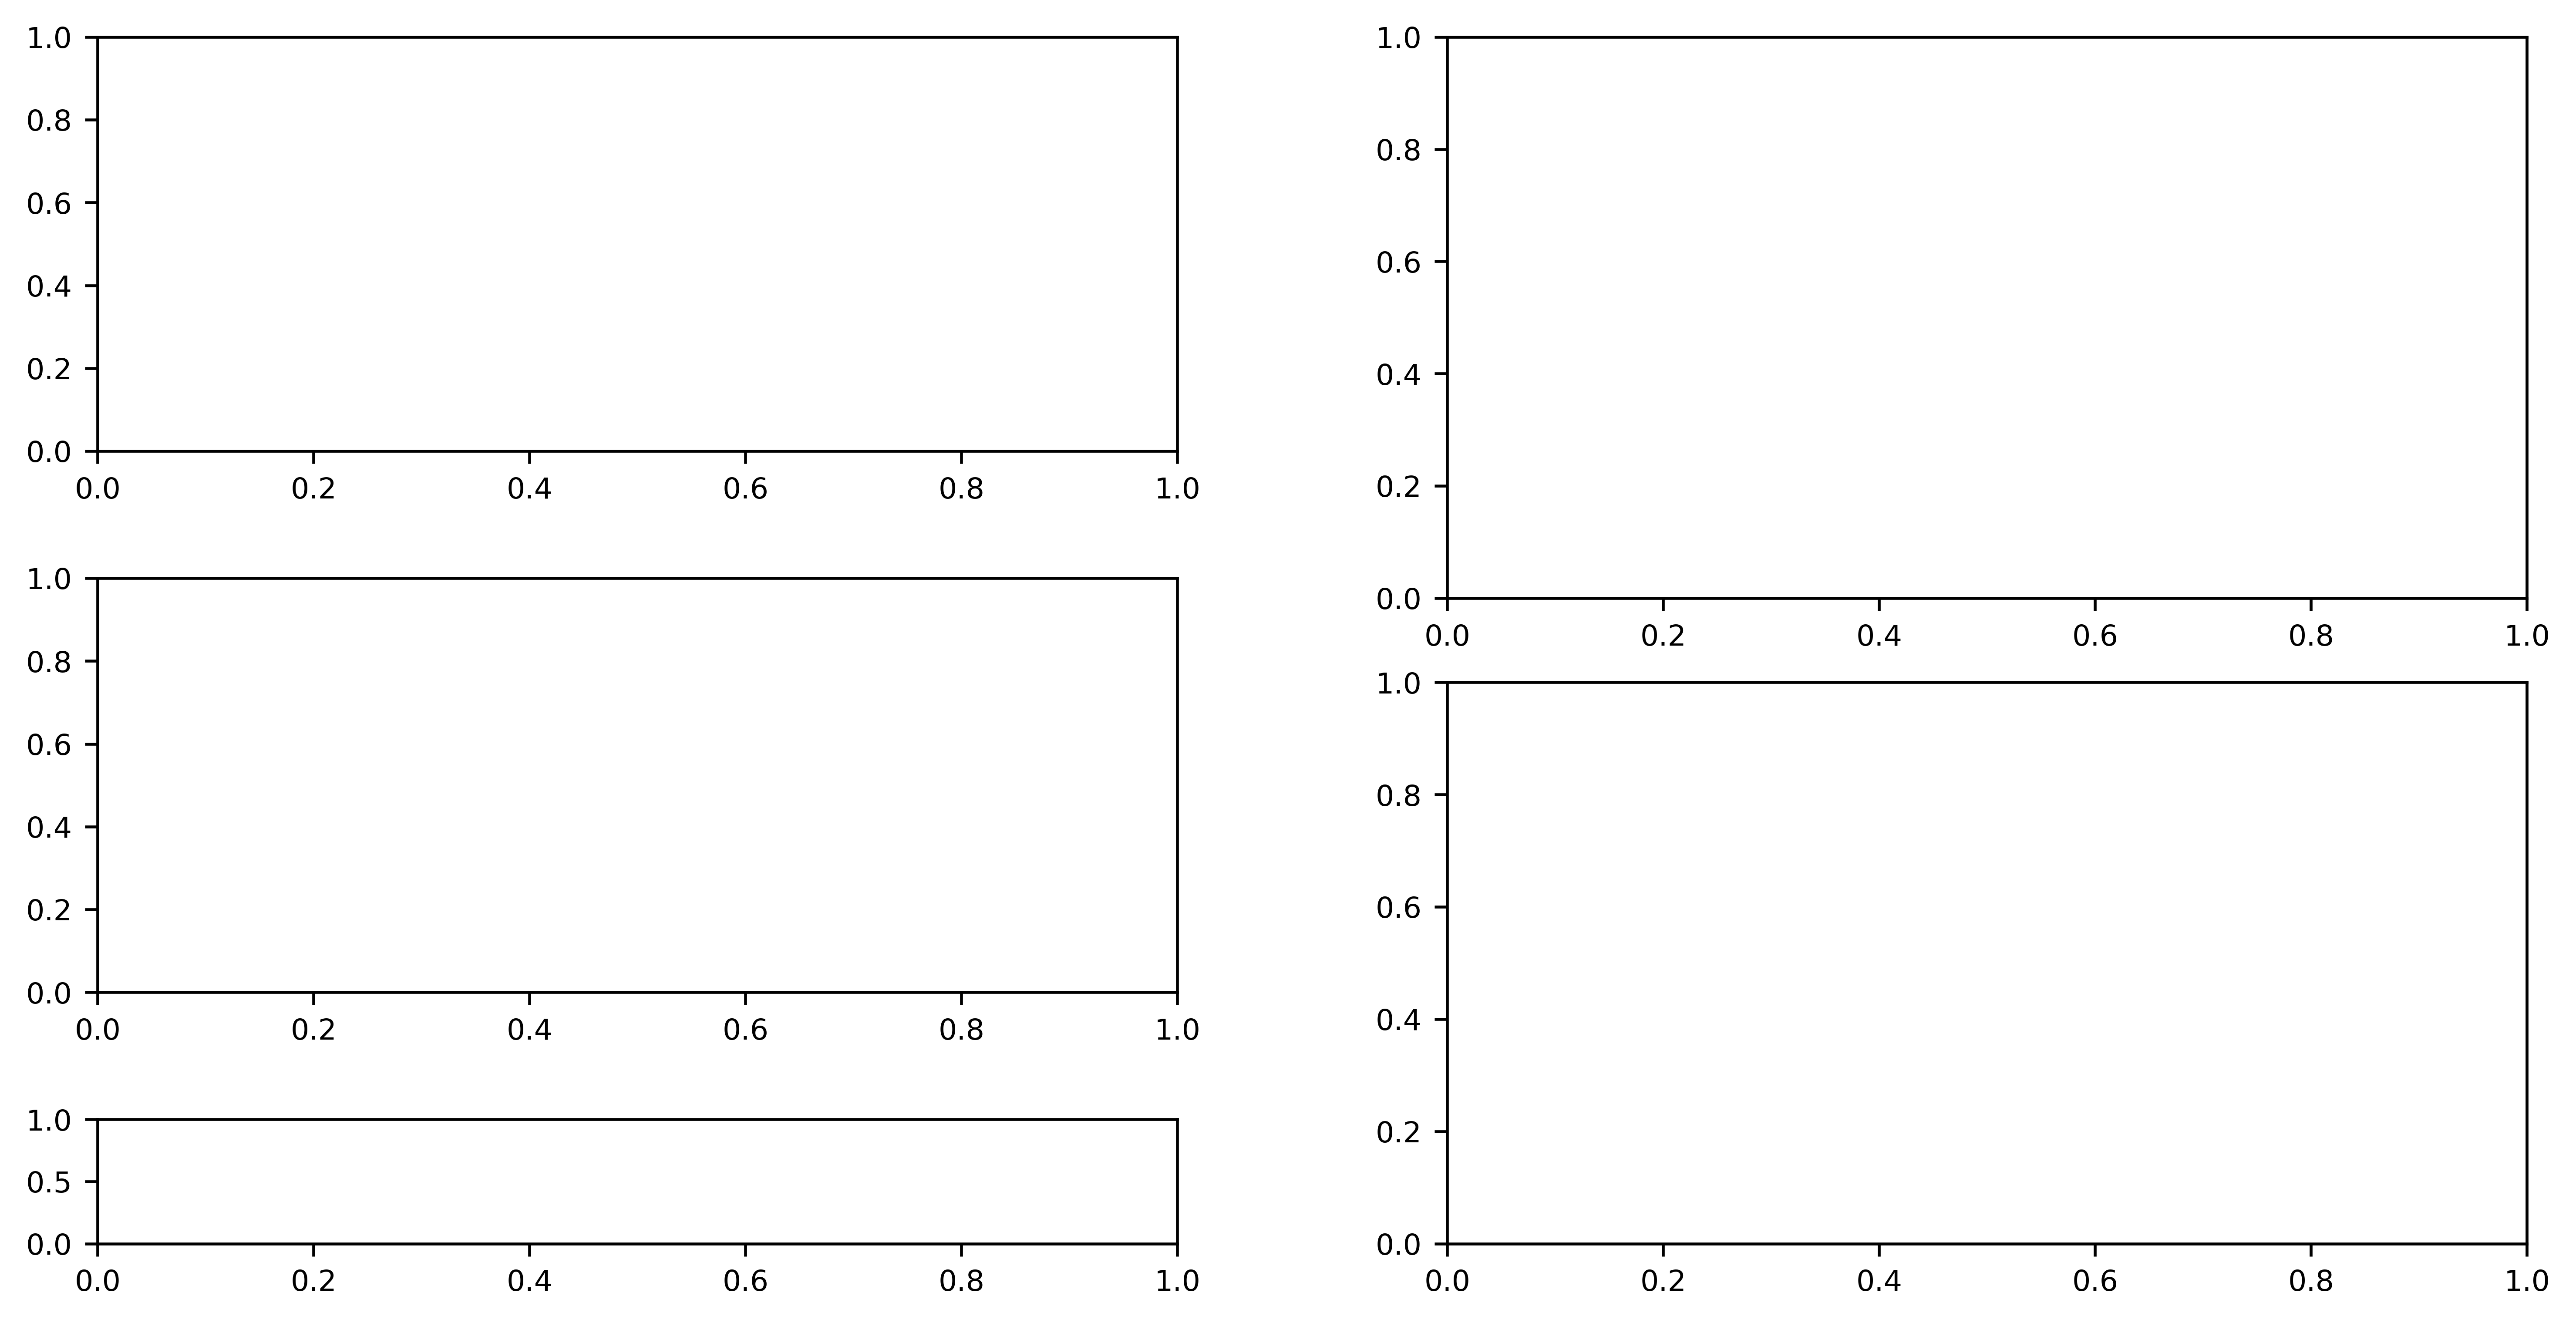

In [ ]:
# --- side-by-side figure (Multi (3 rows) | Single (2 rows)) ---
# Assumes you have: SystemParams, LeaderLBSolver, simulate_leader, simulate_follower,
# compute_a_grid, compute_f_grid, compute_b_grid, int_trapz, DeepLSTMController, make_nn_policy.

import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

# ---------- style ----------
plt.rcParams.update({
    "font.size": 8,
    "font.weight": 550,
    "axes.titleweight": 575,
    "axes.labelweight": 575,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "lines.linewidth": 2.0,
    "lines.markersize": 5,
    "hatch.linewidth": 4.0,
    'mathtext.fontset': 'cm',  
    'mathtext.default': 'regular',
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------- high-level layout: 1 row × 2 cols; each col gets its own subgridspec ----------
fig = plt.figure(figsize=(12, 6), dpi=600)
gs_main = GridSpec(1, 2, figure=fig, width_ratios=[1.0, 1.0], wspace=0.25)

# Left column: 3 rows (M est, Var, Legend)
gs_left = gs_main[0, 0].subgridspec(3, 1, height_ratios=[1.0, 1.0, 0.3], hspace=0.4)
axL_top = fig.add_subplot(gs_left[0, 0])   # Multi: M estimation
axL_bot = fig.add_subplot(gs_left[1, 0])   # Multi: variance
axL_leg = fig.add_subplot(gs_left[2, 0])   # Multi: legend panel (axes off later)

# Right column: 2 rows (M est, Var)
gs_right = gs_main[0, 1].subgridspec(2, 1, height_ratios=[1.0, 1.0], hspace=0.15)
axR_top = fig.add_subplot(gs_right[0, 0])  # Single: M estimation
axR_bot = fig.add_subplot(gs_right[1, 0])  # Single: variance

# ============================================================================================
# LEFT COLUMN: MULTI-PERIOD ESTIMATION (computations unchanged)
# ============================================================================================

# params for left column
N_L = 50
T_L = 0.5

params_L = SystemParams()
params_L.A_L, params_L.A_F = -1.0, -1.0
params_L.B_L, params_L.B_F = 1.0, 1.0
params_L.sig_L, params_L.sig_F = 0.1, 0.1
params_L.M_true = 1.0
params_L.lamb_F = 1.0
params_L.Q_L_T = 1.0
params_L.Q_L, params_L.Q_F = 1.0, 1.0
params_L.R_L, params_L.R_F = 1.0, 1.0
params_L.X_L_0, params_L.X_F_0 = 0.1, 0.1
params_L.T, params_L.N = T_L, N_L
params_L.device = device
params_L.time_grid = torch.linspace(0, params_L.T, params_L.N + 1, device=params_L.device)
params_L.dt = params_L.T / params_L.N

def F_L(x):
    return 0.2 * torch.sin(2*np.pi * x / params_L.T)

num_periods = 50
analy_lamb_L_vals = [0.65, 0.93, 1.1335]                 # FIM (analytic) controls
var_weight_files = [
    (1e-7, "/runs/soothing_residences/loss_4.875e-02_upd_10153.pt"),
    (1e-6, "/runs/remained_resting/loss_1.762e-01_upd_15000.pt"),
    (1e-5, "/runs/tryin_exceed/loss_6.298e-01_upd_15000.pt"),
    # (1e-7, "/runs/pensions_characterize/final_weights.pt"),
    # (1e-6, "/runs/prisoners_troopers/final_weights.pt"),
    # (1e-5, "/runs/playground_amir/final_weights.pt"),
]                                                       # Var-min (NN) controls

estM_L, varM_L = {}, {}

# ---- FIM analytic policies (dashed in plots) ----
for lam in analy_lamb_L_vals:
    params_L.lamb_L = lam
    leader_analytic = LeaderLBSolver(params_L, F_L)
    curr_X_L_0, curr_X_F_0 = 0.1, 0.1
    running_prec = [0.0]
    running_estM = [0.0]
    running_var  = [0.0]
    for i in range(num_periods):
        params_L.X_L_0, params_L.X_F_0 = curr_X_L_0, curr_X_F_0
        X_L, U_L = leader_analytic.simulate(batch=1, seed=2*i)
        X_F, U_F = simulate_follower(X_L, params_L, batch=1, seed=2*i+1)

        a_grid = compute_a_grid(params_L)
        f_grid = compute_f_grid(params_L)
        g = compute_b_grid(params_L, a_grid, X_L) / params_L.M_true

        num_first = int_trapz(f_grid[1:-1] * g * X_F, params_L.dt)
        num_second = sum([g[0, j] * (X_F[0, j+1] - X_F[0, j]) for j in range(X_F.shape[1] - 1)])
        denom = int_trapz((params_L.B_F**2/params_L.R_F) * (g**2), params_L.dt)
        curr_M = (num_first - num_second) / denom

        running_prec.append(running_prec[-1] + int_trapz(g**2, params_L.dt))
        new_M_est = (running_prec[-2]/running_prec[-1]) * running_estM[-1] \
                  + (int_trapz(g**2, params_L.dt)/running_prec[-1]) * curr_M
        new_var_est = ((params_L.sig_F**2 * params_L.R_F**2)/(params_L.B_F**4)) * (1/running_prec[-1])

        if torch.isnan(new_M_est):  new_M_est  = running_estM[-1]
        if torch.isnan(new_var_est): new_var_est = running_var[-1]

        running_estM.append(new_M_est)
        running_var.append(new_var_est)

        curr_X_L_0 = X_L[0, -1].item()
        curr_X_F_0 = X_F[0, -1].item()

    estM_L[lam] = running_estM[1:]
    varM_L[lam] = running_var[1:]

# ---- Baseline (λ=0) ----
params_L.lamb_L = 0.0
baseline_solver = LeaderLBSolver(params_L, F_L)
curr_X_L_0, curr_X_F_0 = 0.1, 0.1
running_estM = [0.0]
running_prec = [0.0]
running_var  = [0.0]
for i in range(num_periods):
    params_L.X_L_0, params_L.X_F_0 = curr_X_L_0, curr_X_F_0
    X_L, U_L = baseline_solver.simulate(batch=1, seed=2*i)
    X_F, U_F = simulate_follower(X_L, params_L, batch=1, seed=2*i+1)

    a_grid = compute_a_grid(params_L)
    f_grid = compute_f_grid(params_L)
    g = compute_b_grid(params_L, a_grid, X_L) / params_L.M_true

    num_first = int_trapz(f_grid[1:-1] * g * X_F, params_L.dt)
    num_second = sum([g[0, j] * (X_F[0, j+1] - X_F[0, j]) for j in range(X_F.shape[1] - 1)])
    denom = int_trapz((params_L.B_F**2/params_L.R_F) * (g**2), params_L.dt)
    curr_M = (num_first - num_second) / denom

    running_prec.append(running_prec[-1] + int_trapz(g**2, params_L.dt))
    new_M_est = (running_prec[-2]/running_prec[-1]) * running_estM[-1] \
              + (int_trapz(g**2, params_L.dt)/running_prec[-1]) * curr_M
    new_var_est = ((params_L.sig_F**2 * params_L.R_F**2)/(params_L.B_F**4)) * (1/running_prec[-1])

    if torch.isnan(new_M_est):  new_M_est  = running_estM[-1]
    if torch.isnan(new_var_est): new_var_est = running_var[-1]

    running_estM.append(new_M_est)
    running_var.append(new_var_est)

    curr_X_L_0 = X_L[0, -1].item()
    curr_X_F_0 = X_F[0, -1].item()

baseline_estM_L = running_estM[1:]
baseline_varM_L = running_var[1:]

# ---- Var-control (NN) runs (solid in plots) ----
var_lams = [v for v, _ in var_weight_files]
for lam_exact_val, weight_file in var_weight_files:
    net = DeepLSTMController(num_layers=2)
    net.load_state_dict(torch.load(os.getcwd() + weight_file, map_location=device))
    net.to(device)
    u_NN = make_nn_policy(net, params_L)

    curr_X_L_0, curr_X_F_0 = 0.1, 0.1
    running_prec = [0.0]
    running_estM = [0.0]
    running_var  = [0.0]
    for i in range(num_periods):
        params_L.X_L_0, params_L.X_F_0 = curr_X_L_0, curr_X_F_0
        X_L, U_L = simulate_leader(u_NN, params_L, batch=1, seed=2*i)
        X_L, U_L = X_L.detach(), U_L.detach()
        X_F, U_F = simulate_follower(X_L, params_L, batch=1, seed=2*i+1)

        a_grid = compute_a_grid(params_L)
        f_grid = compute_f_grid(params_L)
        g = compute_b_grid(params_L, a_grid, X_L) / params_L.M_true

        num_first = int_trapz(f_grid[1:-1] * g * X_F, params_L.dt)
        num_second = sum([g[0, j] * (X_F[0, j+1] - X_F[0, j]) for j in range(X_F.shape[1] - 1)])
        denom = int_trapz((params_L.B_F**2/params_L.R_F) * (g**2), params_L.dt)
        curr_M = (num_first - num_second) / denom

        running_prec.append(running_prec[-1] + int_trapz(g**2, params_L.dt))
        new_M_est = (running_prec[-2]/running_prec[-1]) * running_estM[-1] \
                  + (int_trapz(g**2, params_L.dt)/running_prec[-1]) * curr_M
        new_var_est = ((params_L.sig_F**2 * params_L.R_F**2)/(params_L.B_F**4)) * (1/running_prec[-1])

        if torch.isnan(new_M_est):  new_M_est  = running_estM[-1]
        if torch.isnan(new_var_est): new_var_est = running_var[-1]

        running_estM.append(new_M_est)
        running_var.append(new_var_est)

        curr_X_L_0 = X_L[0, -1].item()
        curr_X_F_0 = X_F[0, -1].item()

    estM_L[lam_exact_val] = running_estM[1:]
    varM_L[lam_exact_val] = running_var[1:]

# ---- PLOTTING (LEFT): Var = solid; FIM = dashed; same color per index ----
colors = [f"C{i}" for i in range(max(len(analy_lamb_L_vals), len(var_lams)))]

# M estimation (top-left)
for idx, lam in enumerate(var_lams):
    axL_top.plot(torch.abs(params.M_true - torch.tensor(estM_L[lam])), color=colors[idx], linestyle='-', 
                 label=rf'Var control, $\lambda$ = {lam:.0e}')
for idx, lam in enumerate(analy_lamb_L_vals):
    axL_top.plot(torch.abs(params.M_true - torch.tensor(estM_L[lam])), color=colors[idx], linestyle='--', 
                 label=rf'FIM control, $\lambda$ = {lam}')
axL_top.plot(torch.abs(params.M_true - torch.tensor(baseline_estM_L)), color='k', linestyle='-',
             label=r'Baseline, $\lambda$=0')
# axL_top.axhline(params_L.M_true, color='black', linestyle='dashdot', label='True M')
axL_top.set_ylabel(r'$\left|M - \widehat{M}\right|$')
# axL_top.set_ylim(-0.1, 5)
axL_top.set_yscale('log')
axL_top.set_title('Multi-period Estimation of $M$')
axL_top.grid(True)

# Variance (bottom-left)
for idx, lam in enumerate(var_lams):
    axL_bot.plot(varM_L[lam], color=colors[idx], linestyle='-', 
                 label=rf'Var control, $\lambda$ = {lam:.0e}')
for idx, lam in enumerate(analy_lamb_L_vals):
    axL_bot.plot(varM_L[lam], color=colors[idx], linestyle='--', 
                 label=rf'FIM control, $\lambda$ = {lam}')
axL_bot.plot(baseline_varM_L, color='k', linestyle='-',
             label=r'Baseline, $\lambda$=0')
axL_bot.set_ylabel(r'Var$\left[\widehat{M}\right]$')
axL_bot.set_xlabel('Period')
axL_bot.set_yscale('log')
axL_bot.set_ylim(1e-6, 1e2)
axL_bot.grid(True)

# Legend panel (left, bottom)
axL_leg.set_axis_off()
legend_handles = []
for idx in range(len(analy_lamb_L_vals)):
    legend_handles.append(Line2D([0],[0], color=colors[idx], linestyle='-', 
                                 label=rf'Var: $\lambda$={var_lams[idx]:.0e}'))
    legend_handles.append(Line2D([0],[0], color=colors[idx], linestyle='--',
                                 label=rf'FIM: $\lambda$={analy_lamb_L_vals[idx]}'))
legend_handles += [
    Line2D([0],[0], color='k', linestyle='-',  label=r'Baseline, $\lambda$=0'),
    # Line2D([0],[0], color='k', linestyle='dashdot', label='True M')
]
leg = axL_leg.legend(
                    handles=legend_handles, 
                    ncol=4, 
                    frameon=True, 
                    title='Multi-period Legend', 
                    loc='center',
                    fontsize=8,
                    title_fontsize=10
                    )
leg.get_title().set_fontweight(575)

# ============================================================================================
# RIGHT COLUMN: SINGLE-PERIOD MONTE CARLO (computations unchanged; two rows)
# ============================================================================================

# params for right column
N_R = 50
T_R = 0.5
seed = 42

params_R = SystemParams()
params_R.A_L, params_R.A_F = -1.0, -1.0
params_R.B_L, params_R.B_F = 1.0, 1.0
params_R.sig_L, params_R.sig_F = 0.1, 0.1
params_R.M_true = 1.0
params_R.lamb_F = 1.0
params_R.lamb_L = 1.5
params_R.Q_L_T = 1.0
params_R.Q_L, params_R.Q_F = 1.0, 1.0
params_R.R_L, params_R.R_F = 1.0, 1.0
params_R.X_L_0, params_R.X_F_0 = 0.1, 0.1
params_R.T, params_R.N = T_R, N_R
params_R.device = device
params_R.time_grid = torch.linspace(0, params_R.T, params_R.N + 1, device=params_R.device)
params_R.dt = params_R.T / params_R.N

def F_R(x):
    return 0.2 * torch.sin(2*np.pi * x / params_R.T)

num_single_periods = [i for i in range(50, 10000, 100)]
estM_R, varM_R, theoretical_var_R = {}, {}, {}

leader_analytic_R = LeaderLBSolver(params_R, F_R)
num_leader_samples = 10
X_L_batch, U_L_batch = leader_analytic_R.simulate(batch=num_leader_samples, seed=2*seed+num_leader_samples)

for val in range(1, num_leader_samples+1):
    X_L = X_L_batch[val-1:val]
    a_grid = compute_a_grid(params_R)
    f_grid = compute_f_grid(params_R)
    g = compute_b_grid(params_R, a_grid, X_L) / params_R.M_true
    denom = int_trapz((g**2), params_R.dt)

    running_estM = []
    running_var  = []
    for size in num_single_periods:
        X_F, U_F = simulate_follower(X_L, params_R, batch=size, seed=seed+val)
        num_first  = torch.einsum('i,ji,ji->j', f_grid[1:-1], g, X_F) * params_R.dt
        num_second = torch.sum(g[:, :-1] * (X_F[:, 1:] - X_F[:, :-1]), dim=1)
        emp_Mhat = (num_first - num_second) / ((params_R.B_F**2/params_R.R_F) * denom)
        running_estM.append(emp_Mhat.mean())
        running_var.append(emp_Mhat.var())

    estM_R[val] = running_estM
    varM_R[val] = running_var
    theoretical_var_R[val] = (params_R.sig_F**2 / ((params_R.B_F**4/params_R.R_F**2)*denom)).item()

# unconditional theoretical variance
X_L_uncond, U_L_uncond = leader_analytic_R.simulate(batch=10000, seed=2*seed+num_leader_samples)
a_grid_un = compute_a_grid(params_R)
f_grid_un = compute_f_grid(params_R)
g_un = compute_b_grid(params_R, a_grid_un, X_L_uncond) / params_R.M_true
denom_un = int_trapz((g_un**2), params_R.dt)
theoretical_var_uncond = (params_R.sig_F**2 / ((params_R.B_F**4/params_R.R_F**2) * denom_un)).mean().item()

# ---- PLOTTING (RIGHT): two rows ----
for val in range(1, num_leader_samples+1):
    axR_top.plot(num_single_periods, torch.abs(params.M_true - torch.tensor(estM_R[val])), linestyle='-', color=f'C{val}')
# axR_top.axhline(params_R.M_true, color='black', linestyle='dashdot', label='True M')
axR_top.set_ylabel(r'$\left|M - \widehat{M}\right|$')
# axR_top.set_ylim(-0.1, 4.0)
axR_top.set_yscale('log')
axR_top.set_title('Single-period Monte Carlo Estimation of $M$')
axR_top.grid(True)

for val in range(1, num_leader_samples+1):
    axR_bot.plot(num_single_periods, varM_R[val], linestyle='-',  color=f'C{val}')
    axR_bot.axhline(theoretical_var_R[val], linestyle='dashed', color=f'C{val}')
axR_bot.axhline(theoretical_var_uncond, color='black', linestyle='dashed', label='Theoretical Unconditional Var')
axR_bot.set_ylabel(r'Var$\left[\widehat{M}|x^L \right]$')
axR_bot.set_xlabel(r'Number of $X^F$ samples')
axR_bot.grid(True)

plt.tight_layout()
plt.show()

/var/folders/bs/pjtn_x6x0vlg303wglbxqthm0000gn/T/ipykernel_4029/733937072.py:190: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net.load_state_dict(torch.load(os.getcwd() + 

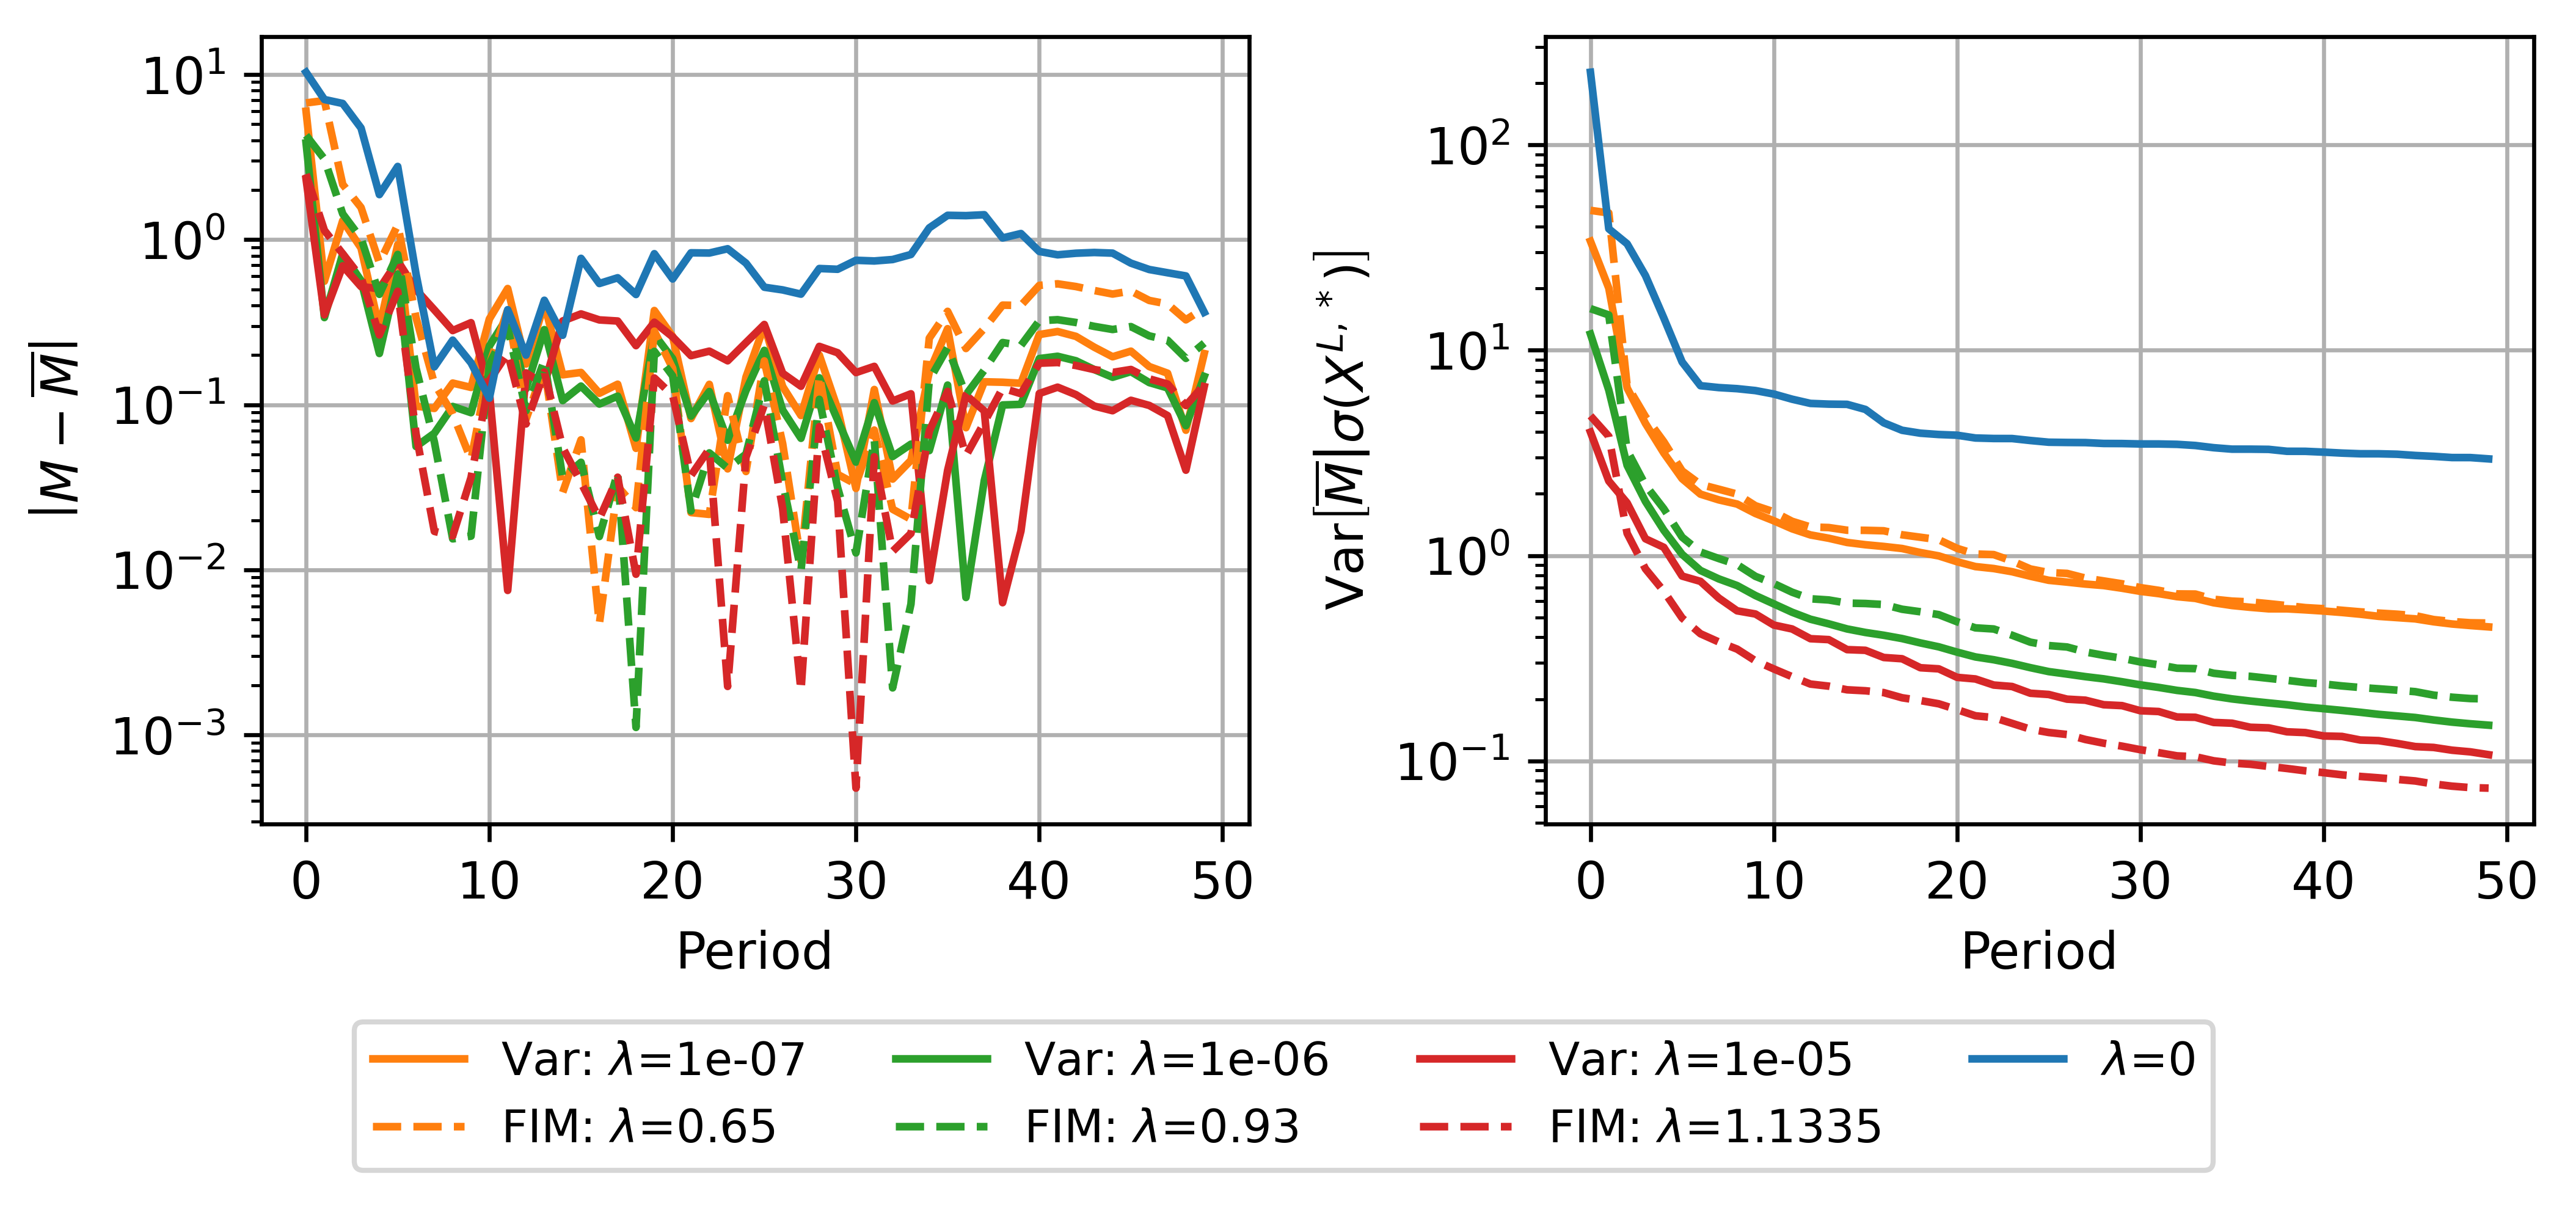

In [127]:
# multi_period_plot.py
# Assumes you have: SystemParams, LeaderLBSolver, simulate_leader, simulate_follower,
# compute_a_grid, compute_f_grid, compute_b_grid, int_trapz, DeepLSTMController, make_nn_policy.

import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

seed = 42

# # ---------- style ----------
# plt.rcParams.update({
#     "font.size": 8,
#     "font.weight": 550,
#     "axes.titleweight": 575,
#     "axes.labelweight": 575,
#     "axes.titlesize": 12,
#     "axes.labelsize": 10,
#     "xtick.labelsize": 8,
#     "ytick.labelsize": 8,
#     "legend.fontsize": 8,
#     "lines.linewidth": 2.0,
#     "lines.markersize": 5,
#     "hatch.linewidth": 4.0,
#     'mathtext.fontset': 'cm',
#     'mathtext.default': 'regular',
# })

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.set_default_dtype(torch.float64)

# ============================================================================================
# MULTI-PERIOD ESTIMATION (computations)
# ============================================================================================

# params
N_L = 50
T_L = 0.5

params_L = SystemParams()
params_L.A_L, params_L.A_F = -1.0, -1.0
params_L.B_L, params_L.B_F = 1.0, 1.0
params_L.sig_L, params_L.sig_F = 0.1, 0.1
params_L.M_true = 1.0
params_L.lamb_F = 1.0
params_L.Q_L_T = 1.0
params_L.Q_L, params_L.Q_F = 1.0, 1.0
params_L.R_L, params_L.R_F = 1.0, 1.0
params_L.X_L_0, params_L.X_F_0 = 0.1, 0.1
params_L.T, params_L.N = T_L, N_L
params_L.device = device
params_L.time_grid = torch.linspace(0, params_L.T, params_L.N + 1, device=params_L.device)
params_L.dt = params_L.T / params_L.N

def F_L(x):
    return 0.2 * torch.sin(2*np.pi * x / params_L.T)

num_periods = 50
analy_lamb_L_vals = [0.65, 0.93, 1.1335]  # FIM (analytic) controls

var_weight_files = [
    (1e-7, "/runs/soothing_residences/loss_4.875e-02_upd_10153.pt"),
    (1e-6, "/runs/remained_resting/loss_1.762e-01_upd_15000.pt"),
    (1e-5, "/runs/tryin_exceed/loss_6.298e-01_upd_15000.pt"),
]  # Var-min (NN) controls
var_lams = [lam for lam, _ in var_weight_files]

# FI_weight_files = [
#     (0.65, "/runs/vincent_daniels/loss_-1.003e-02_upd_2402.pt"),
#     (0.93, "/runs/extended_hasn't/loss_-2.849e-02_upd_5510.pt"),
#     (1.1335, "/runs/posts_planned/loss_-6.618e-02_upd_9975.pt"),
# ]  
# FI_lams = [lam for lam, _ in FI_weight_files]

estM_L, varM_L = {}, {}

# ---- FIM analytic policies (dashed) ----
for lam in analy_lamb_L_vals:
    params_L.lamb_L = lam
    leader_analytic = LeaderLBSolver(params_L, F_L)

    # Wrap analytic u*(k, r) to be usable by simulate_leader (which passes x only)
    h_grid, k_grid, dt = leader_analytic.h_grid, leader_analytic.k_grid, params_L.dt
    def make_u_analytic_period():
        y = None
        z = None
        def u_analytic(k, x):
            nonlocal y, z
            if k == 0:
                # reset augmented states at the start of each *period*
                y = torch.zeros_like(x)
                z = torch.zeros_like(x)
            r = torch.stack((x, y, z), dim=1)                # (B,3)
            u = leader_analytic.u_star(k, r).reshape(-1)     # (B,)
            # advance Y, Z to next step
            y = y + (-h_grid[k] * x) * dt
            z = z + k_grid[k] * y * dt
            return u
        return u_analytic

    running_prec = [0.0]
    running_estM = [0.0]
    running_var  = [0.0]

    for i in range(num_periods):
        # >>> INDEPENDENT TRIALS: reset initial conditions every period <<<
        params_L.X_L_0 = 0.1
        params_L.X_F_0 = 0.1

        u_analytic = make_u_analytic_period()  # fresh Y,Z for this period

        with torch.no_grad():
            # use same simulator as NN
            X_L, U_L = simulate_leader(u_analytic, params_L, batch=1, seed=seed+num_periods+i)
            X_F, U_F = simulate_follower(X_L, params_L, batch=1, seed=seed+i)

        a_grid = compute_a_grid(params_L)
        f_grid = compute_f_grid(params_L)
        g = compute_b_grid(params_L, a_grid, X_L) / params_L.M_true

        num_first  = int_trapz(f_grid[1:-1] * g * X_F, params_L.dt)
        num_second = sum(g[0, j] * (X_F[0, j+1] - X_F[0, j]) for j in range(X_F.shape[1] - 1))
        denom      = int_trapz((params_L.B_F**2/params_L.R_F) * (g**2), params_L.dt)
        curr_M     = (num_first - num_second) / denom

        delta_I = int_trapz(g**2, params_L.dt)
        running_prec.append(running_prec[-1] + delta_I)

        new_M_est  = (running_prec[-2]/running_prec[-1]) * running_estM[-1] \
                   + (delta_I/running_prec[-1]) * curr_M
        new_var_est = ((params_L.sig_F**2 * params_L.R_F**2)/(params_L.B_F**4)) * (1.0 / running_prec[-1])

        if torch.isnan(new_M_est):   new_M_est  = running_estM[-1]
        if torch.isnan(new_var_est): new_var_est = running_var[-1]

        running_estM.append(new_M_est)
        running_var.append(new_var_est)

    estM_L[lam] = running_estM[1:]
    varM_L[lam] = running_var[1:]



# ---- Baseline (λ=0) ----
params_L.lamb_L = 0.0
baseline_solver = LeaderLBSolver(params_L, F_L)
curr_X_L_0, curr_X_F_0 = 0.1, 0.1
running_estM = [0.0]
running_prec = [0.0]
running_var  = [0.0]
for i in range(num_periods):
    params_L.X_L_0, params_L.X_F_0 = curr_X_L_0, curr_X_F_0
    X_L, U_L = baseline_solver.simulate(batch=1, seed=seed+num_periods+i)
    X_F, U_F = simulate_follower(X_L, params_L, batch=1, seed=seed+i)

    a_grid = compute_a_grid(params_L)
    f_grid = compute_f_grid(params_L)
    g = compute_b_grid(params_L, a_grid, X_L) / params_L.M_true

    num_first = int_trapz(f_grid[1:-1] * g * X_F, params_L.dt)
    num_second = sum([g[0, j] * (X_F[0, j+1] - X_F[0, j]) for j in range(X_F.shape[1] - 1)])
    denom = int_trapz((params_L.B_F**2/params_L.R_F) * (g**2), params_L.dt)
    curr_M = (num_first - num_second) / denom

    running_prec.append(running_prec[-1] + int_trapz(g**2, params_L.dt))
    new_M_est = (running_prec[-2]/running_prec[-1]) * running_estM[-1] \
              + (int_trapz(g**2, params_L.dt)/running_prec[-1]) * curr_M
    new_var_est = ((params_L.sig_F**2 * params_L.R_F**2)/(params_L.B_F**4)) * (1/running_prec[-1])

    if torch.isnan(new_M_est):   new_M_est  = running_estM[-1]
    if torch.isnan(new_var_est): new_var_est = running_var[-1]

    running_estM.append(new_M_est)
    running_var.append(new_var_est)

    curr_X_L_0 = X_L[0, -1].item()
    curr_X_F_0 = X_F[0, -1].item()

baseline_estM_L = running_estM[1:]
baseline_varM_L = running_var[1:]

# ---- Var-control (NN) runs (solid) ----
for lam_exact_val, weight_file in var_weight_files:
    params_L.lamb_L = lam_exact_val
    net = DeepLSTMController(num_layers=2)
    net.load_state_dict(torch.load(os.getcwd() + weight_file, map_location=device))
    net.to(device)
    u_NN = make_nn_policy(net, params_L)

    curr_X_L_0, curr_X_F_0 = 0.1, 0.1
    running_prec = [0.0]
    running_estM = [0.0]
    running_var  = [0.0]
    for i in range(num_periods):
        net.reset_state(B=1)
        params_L.X_L_0, params_L.X_F_0 = curr_X_L_0, curr_X_F_0
        X_L, U_L = simulate_leader(u_NN, params_L, batch=1, seed=seed+num_periods+i)
        X_L, U_L = X_L.detach(), U_L.detach()
        X_F, U_F = simulate_follower(X_L, params_L, batch=1, seed=seed+i)

        a_grid = compute_a_grid(params_L)
        f_grid = compute_f_grid(params_L)
        g = compute_b_grid(params_L, a_grid, X_L) / params_L.M_true

        num_first = int_trapz(f_grid[1:-1] * g * X_F, params_L.dt)
        num_second = sum([g[0, j] * (X_F[0, j+1] - X_F[0, j]) for j in range(X_F.shape[1] - 1)])
        denom = int_trapz((params_L.B_F**2/params_L.R_F) * (g**2), params_L.dt)
        curr_M = (num_first - num_second) / denom

        running_prec.append(running_prec[-1] + int_trapz(g**2, params_L.dt))
        new_M_est = (running_prec[-2]/running_prec[-1]) * running_estM[-1] \
                  + (int_trapz(g**2, params_L.dt)/running_prec[-1]) * curr_M
        new_var_est = ((params_L.sig_F**2 * params_L.R_F**2)/(params_L.B_F**4)) * (1/running_prec[-1])

        if torch.isnan(new_M_est):   new_M_est  = running_estM[-1]
        if torch.isnan(new_var_est): new_var_est = running_var[-1]

        running_estM.append(new_M_est)
        running_var.append(new_var_est)

        curr_X_L_0 = X_L[0, -1].item()
        curr_X_F_0 = X_F[0, -1].item()

    estM_L[lam_exact_val] = running_estM[1:]
    varM_L[lam_exact_val] = running_var[1:]

# # FIM-control (NN) runs (dashed)
# for lam_exact_val, weight_file in FI_weight_files:
#     params_L.lamb_L = lam_exact_val
#     net = DeepLSTMController(num_layers=2)
#     net.load_state_dict(torch.load(os.getcwd() + weight_file, map_location=device))
#     net.to(device)
#     u_NN = make_nn_policy(net, params_L)

#     curr_X_L_0, curr_X_F_0 = 0.1, 0.1
#     running_prec = [0.0]
#     running_estM = [0.0]
#     running_var  = [0.0]
#     for i in range(num_periods):
#         net.reset_state(B=1)
#         params_L.X_L_0, params_L.X_F_0 = curr_X_L_0, curr_X_F_0
#         X_L, U_L = simulate_leader(u_NN, params_L, batch=1, seed=seed+num_periods+i)
#         X_L, U_L = X_L.detach(), U_L.detach()
#         X_F, U_F = simulate_follower(X_L, params_L, batch=1, seed=seed+i)

#         a_grid = compute_a_grid(params_L)
#         f_grid = compute_f_grid(params_L)
#         g = compute_b_grid(params_L, a_grid, X_L) / params_L.M_true

#         num_first = int_trapz(f_grid[1:-1] * g * X_F, params_L.dt)
#         num_second = sum([g[0, j] * (X_F[0, j+1] - X_F[0, j]) for j in range(X_F.shape[1] - 1)])
#         denom = int_trapz((params_L.B_F**2/params_L.R_F) * (g**2), params_L.dt)
#         curr_M = (num_first - num_second) / denom

#         running_prec.append(running_prec[-1] + int_trapz(g**2, params_L.dt))
#         new_M_est = (running_prec[-2]/running_prec[-1]) * running_estM[-1] \
#                   + (int_trapz(g**2, params_L.dt)/running_prec[-1]) * curr_M
#         new_var_est = ((params_L.sig_F**2 * params_L.R_F**2)/(params_L.B_F**4)) * (1/running_prec[-1])

#         if torch.isnan(new_M_est):   new_M_est  = running_estM[-1]
#         if torch.isnan(new_var_est): new_var_est = running_var[-1]
#         running_estM.append(new_M_est)
#         running_var.append(new_var_est)
#         curr_X_L_0 = X_L[0, -1].item()
#         curr_X_F_0 = X_F[0, -1].item()
#     estM_L[lam_exact_val] = running_estM[1:]
#     varM_L[lam_exact_val] = running_var[1:]



fig = plt.figure(figsize=(8, 4), dpi=600)
gs = GridSpec(2, 1, figure=fig, height_ratios=[1.0, 0.22], hspace=0.35)
gs_top = gs[0, 0].subgridspec(1, 2, wspace=0.3)

ax_err = fig.add_subplot(gs_top[0, 0])
ax_var = fig.add_subplot(gs_top[0, 1])
ax_leg = fig.add_subplot(gs[1, 0]); ax_leg.set_axis_off()

# Error = |M - M_hat|
for idx, lam in enumerate(var_lams):
    ax_err.plot(torch.abs(torch.tensor(params_L.M_true) - torch.tensor(estM_L[lam])),
                color=f"C{idx+1}", linestyle='-', label=rf'Var control, $\lambda$ = {lam:.0e}')
for idx, lam in enumerate(analy_lamb_L_vals):
    ax_err.plot(torch.abs(torch.tensor(params_L.M_true) - torch.tensor(estM_L[lam])),
                color=f"C{idx+1}", linestyle='--', label=rf'FIM control, $\lambda$ = {lam}')
ax_err.plot(torch.abs(torch.tensor(params_L.M_true) - torch.tensor(baseline_estM_L)),
            color=f"C{0}", linestyle='-', label=r'Baseline, $\lambda$=0')
ax_err.set_ylabel(r'$\left|M - \overline{M}\right|$')
ax_err.set_yscale('log')
ax_err.set_xlabel('Period')
ax_err.grid(True)

# Variance
for idx, lam in enumerate(var_lams):
    ax_var.plot(varM_L[lam], color=f"C{idx+1}", linestyle='-')
for idx, lam in enumerate(analy_lamb_L_vals):
    ax_var.plot(varM_L[lam], color=f"C{idx+1}", linestyle='--')
ax_var.plot(baseline_varM_L, color=f"C{0}", linestyle='-')
ax_var.set_ylabel(r'Var$\left[\overline{M} \middle | \sigma(X^{L,*}) \right]$')
ax_var.set_xlabel('Period')
ax_var.set_yscale('log')
# ax_var.set_ylim(1e-6, 1e2)
ax_var.grid(True)

# Centered legend (bottom)
legend_handles = []
for idx in range(len(analy_lamb_L_vals)):
    legend_handles.append(Line2D([0],[0], color=f"C{idx+1}", linestyle='-',
                                 label=rf'Var: $\lambda$={var_lams[idx]:.0e}'))
    legend_handles.append(Line2D([0],[0], color=f"C{idx+1}", linestyle='--',
                                 label=rf'FIM: $\lambda$={analy_lamb_L_vals[idx]}'))
legend_handles += [Line2D([0],[0], color=f"C{0}", linestyle='-', label=r'$\lambda$=0')]

leg = ax_leg.legend(handles=legend_handles, ncol=4, frameon=True,
                    loc='center', fontsize=9, bbox_to_anchor=(0.45,0.4))

plt.tight_layout()
plt.show()

/Users/danielralston/Desktop/Strategic-Inference-Stackleburg-Games/src/core.py:445: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  U_F[:, k] = torch.tensor((-params.B_F / params.R_F) * (2 * a_grid[k] * X_F[:, k] + b_grid[:, k]), device=params.device)
/var/folders/bs/pjtn_x6x0vlg303wglbxqthm0000gn/T/ipykernel_7169/96275907.py:167: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax_var.set_ylim(0, 2*ymax)
/var/folders/bs/pjtn_x6x0vlg303wglbxqthm0000gn/T/ipykernel_7169/96275907.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


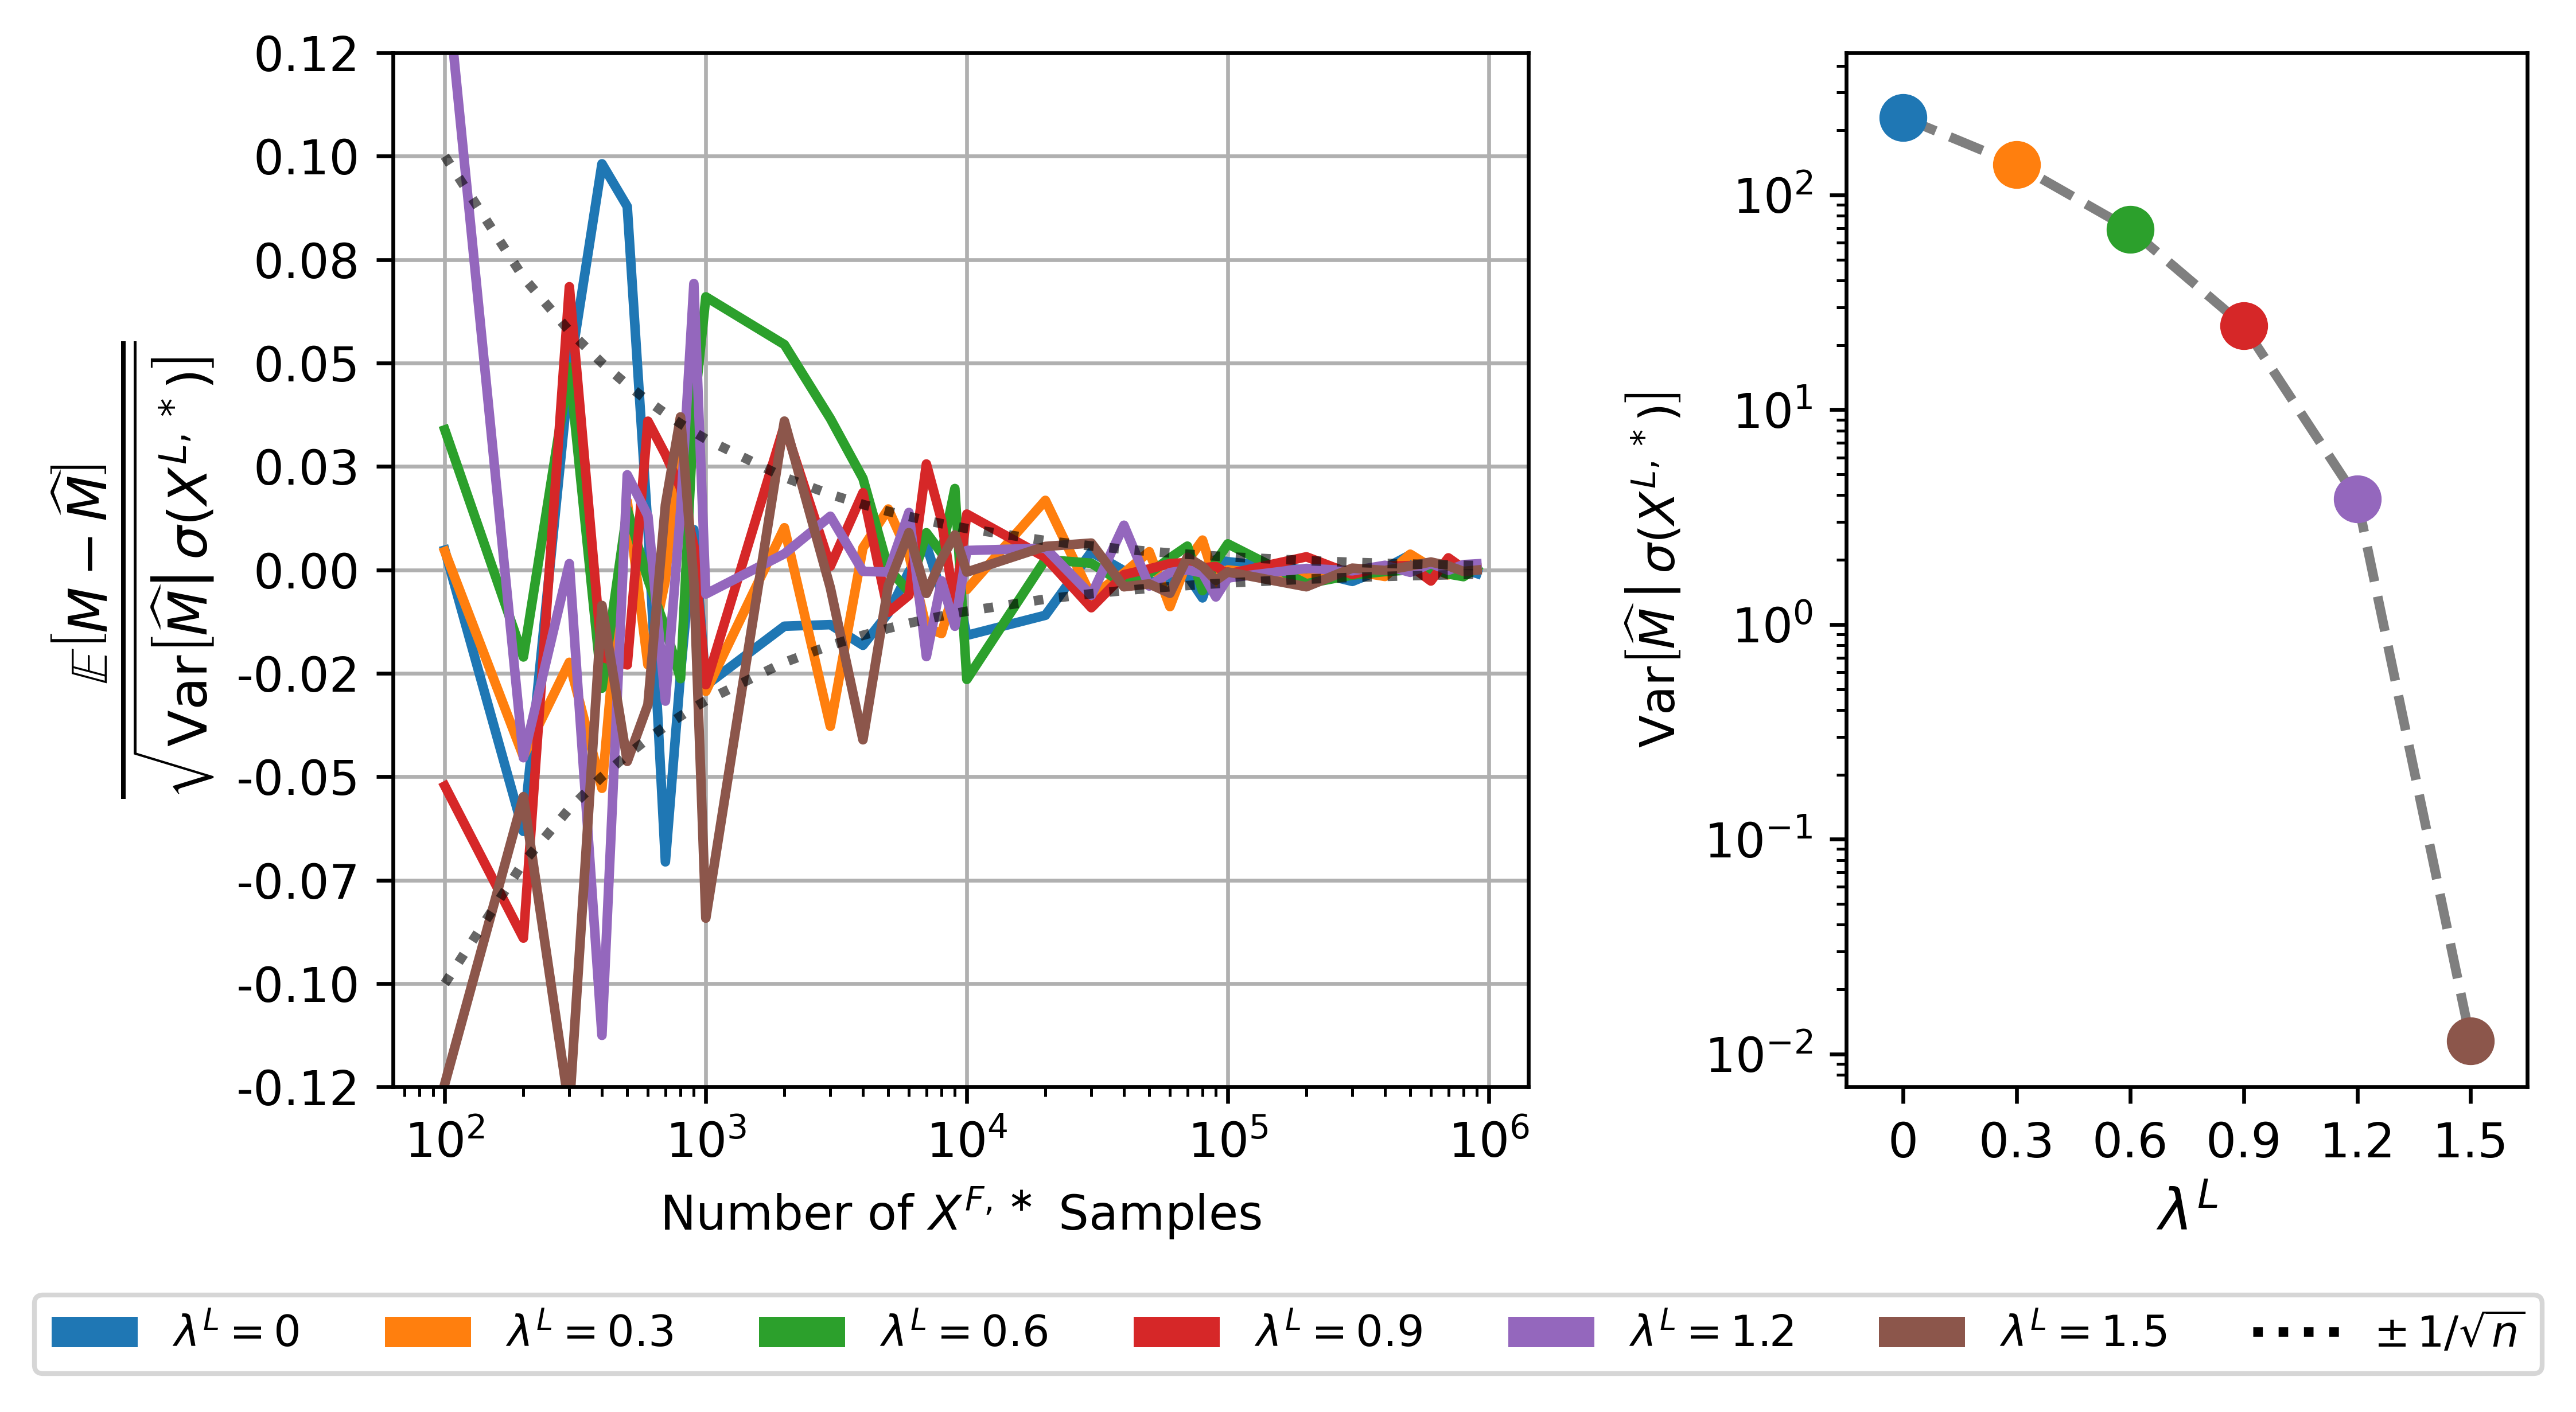

In [18]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

torch.set_default_dtype(torch.float64)

# # ---------- style ----------
# plt.rcParams.update({
#     "font.size": 8,
#     "font.weight": 550,
#     "axes.titleweight": 575,
#     "axes.labelweight": 575,
#     "axes.titlesize": 12,
#     "axes.labelsize": 10,
#     "xtick.labelsize": 8,
#     "ytick.labelsize": 8,
#     "legend.fontsize": 8,
#     "lines.linewidth": 2.0,
#     "lines.markersize": 5,
#     "hatch.linewidth": 4.0,
#     'mathtext.fontset': 'cm',
#     'mathtext.default': 'regular',
# })

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

N_R = 50
T_R = 0.5
seed = 0

params_R = SystemParams()
params_R.A_L, params_R.A_F = -1.0, -1.0
params_R.B_L, params_R.B_F = 1.0, 1.0
params_R.sig_L, params_R.sig_F = 0.1, 0.1
params_R.M_true = 1.0
params_R.lamb_F = 1.0
params_R.lamb_L = 1.5
params_R.Q_L_T = 1.0
params_R.Q_L, params_R.Q_F = 1.0, 1.0
params_R.R_L, params_R.R_F = 1.0, 1.0
params_R.X_L_0, params_R.X_F_0 = 0.1, 0.1
params_R.T, params_R.N = T_R, N_R
params_R.device = device
params_R.time_grid = torch.linspace(0, params_R.T, params_R.N + 1, device=params_R.device)
params_R.dt = params_R.T / params_R.N

def F_R(x):
    return 0.2 * torch.sin(2*np.pi * x / params_R.T)

num_per_order = 9
min_exp = 2
max_exp = 5
num_single_periods = []
for exp in range(2, max_exp+1):
    for mult in range(0, num_per_order):
        num_single_periods.append(10**exp + mult * int((10**(exp+1)-10**exp)/(num_per_order)))

estM_R, varM_R, theoretical_var_R = {}, {}, {}

num_lambda_vals = 6
max_lambda = 1.5
min_lambda = 0
lambda_vals = [min_lambda + i * (max_lambda - min_lambda) / (num_lambda_vals - 1) for i in range(num_lambda_vals)]

leader_analytic_R = LeaderLBSolver(params_R, F_R)
num_leader_samples = 1

# --- figure with bottom legend row ---
fig = plt.figure(figsize=(8, 5), dpi=600)
gs = GridSpec(2, 1, figure=fig, height_ratios=[1.0, 0.22], hspace=0.1)
gs_top = gs[0, 0].subgridspec(1, 2, width_ratios=[1.0, .6], wspace=0.35)

ax_err = fig.add_subplot(gs_top[0, 0])
ax_var = fig.add_subplot(gs_top[0, 1])
ax_leg = fig.add_subplot(gs[1, 0]); ax_leg.set_axis_off()

colors = [f"C{i}" for i in range(len(lambda_vals))]

for i, val in enumerate(lambda_vals):
    params_R.lamb_L = val
    leader_analytic_R = LeaderLBSolver(params_R, F_R)
    X_L, U_L = leader_analytic_R.simulate(batch=num_leader_samples, seed=seed)
    a_grid = compute_a_grid(params_R)
    f_grid = compute_f_grid(params_R)
    g = compute_b_grid(params_R, a_grid, X_L) / params_R.M_true
    denom = int_trapz((g**2), params_R.dt)

    running_estM = []
    running_var  = []
    for size in num_single_periods:
        X_F, U_F = simulate_follower(X_L, params_R, batch=size, seed=seed+num_leader_samples+i+size)
        L  = X_F.shape[1]
        Nf = L - 1

        a_grid = compute_a_grid(params_R)
        f_grid = compute_f_grid(params_R)
        g       = compute_b_grid(params_R, a_grid, X_L) / params_R.M_true

        f_k = f_grid[:Nf]
        g_k = g[:, :Nf]
        Xk  = X_F[:, :Nf]
        dX  = X_F[:, 1:L] - X_F[:, :Nf]
        dt  = params_R.dt

        num_first  = torch.einsum('i,ji,ji->j', f_k, g_k, Xk) * dt
        num_second = torch.sum(g_k * dX, dim=1)
        denom_sum  = torch.einsum('ji,ji->j', g_k, g_k) * dt

        c = (params_R.B_F**2 / params_R.R_F)
        emp_Mhat = (num_first - num_second) / (c * denom_sum)

        running_estM.append(emp_Mhat.mean())
        running_var.append(emp_Mhat.var())

    estM_R[val] = running_estM
    varM_R[val] = running_var
    theoretical_var_R[val] = (params_R.sig_F**2 / ((params_R.B_F**4/params_R.R_F**2) * denom)).item()

    # --- normalized error lines (per lambda) ---
    ax_err.plot(
        num_single_periods,
        (params_R.M_true - torch.tensor(estM_R[val]))/torch.sqrt(torch.tensor(varM_R[val])),
        linestyle='-', color=colors[i], linewidth=2.0
    )

# --- connected line + colored tick marks (variance vs lambda) ---
xs = list(lambda_vals)
ys = [theoretical_var_R[v] for v in xs]

# light black connecting line
ax_var.plot(xs, ys, linestyle='--', color='black', alpha=0.5, linewidth=2.0)

# colored tick marks at each point (match the lambda color)
for i, v in enumerate(xs):
    ax_var.plot([v], [ys[i]],
                linestyle='None',
                marker='o',              
                markersize=8,
                markeredgewidth=2.0,
                color=colors[i],
                zorder=2)

# --- reference lines on error plot ---
ax_err.plot(num_single_periods, [1/np.sqrt(n) for n in num_single_periods], linestyle=':', color='black', alpha=0.6, linewidth=2.0)
ax_err.plot(num_single_periods, [-1/np.sqrt(n) for n in num_single_periods], linestyle=':', color='black', alpha=0.6, linewidth=2.0)
ax_err.grid(True)
ax_err.set_ylabel(r'$\frac{\mathbb{E}\left[M - \widehat{M}\right]}{\sqrt{\mathrm{Var}\left[\widehat{M} \middle|\,\sigma(X^{L,*})\right]}}$', fontsize=16)
ax_err.set_xlabel(r'Number of $X^{F, \ast}$ Samples')
ax_err.set_xscale('log')
ax_err.set_ylim(-(1.1)*max(1/np.sqrt(np.array(num_single_periods))), (1.1)*max(1/np.sqrt(np.array(num_single_periods))))
# make ax_err y axis ticks only 2 decimal places
yticks = ax_err.get_yticks()
ax_err.set_yticks(yticks)
ax_err.set_yticklabels([f"{y:.2f}" for y in yticks])

# --- variance axis formatting (log-safe limits) ---
ax_var.set_yscale('log')
ax_var.set_ylabel(r'Var$\left[\widehat{M}\,\middle|\,\sigma(X^{L,*})\right]$')
ax_var.set_xlabel(r'$\lambda^L$', fontsize=12)
ax_var.set_xticks(lambda_vals)
ax_var.set_xticklabels([f"{v:g}" for v in lambda_vals])
ax_var.set_xlim(min_lambda - 0.15, max_lambda + 0.15)
ymin, ymax = min(ys), max(ys)
ax_var.set_ylim(0, 2*ymax)

# --- centered legend (bottom row) ---
legend_handles = []
for i, val in enumerate(lambda_vals):
    legend_handles.append(Patch(facecolor=colors[i], edgecolor='none', label=rf'$\lambda^L={val:g}$'))
legend_handles.append(Line2D([0],[0], color='k', linestyle=':', label=r'$\pm \, 1/\sqrt{n}$', linewidth=2.0))
# legend_handles.append(Line2D([0],[0], color='k', linestyle='-', alpha=0.35, label='Theoretical var (line + ticks)'))

# plt.subplots_adjust(bottom=0.18)  # give space for legend
fig.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.45, 0.1),
    ncol=num_lambda_vals+1,
    frameon=True,
    fontsize=9,
)

plt.tight_layout()
plt.show()

/var/folders/bs/pjtn_x6x0vlg303wglbxqthm0000gn/T/ipykernel_7169/352389852.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


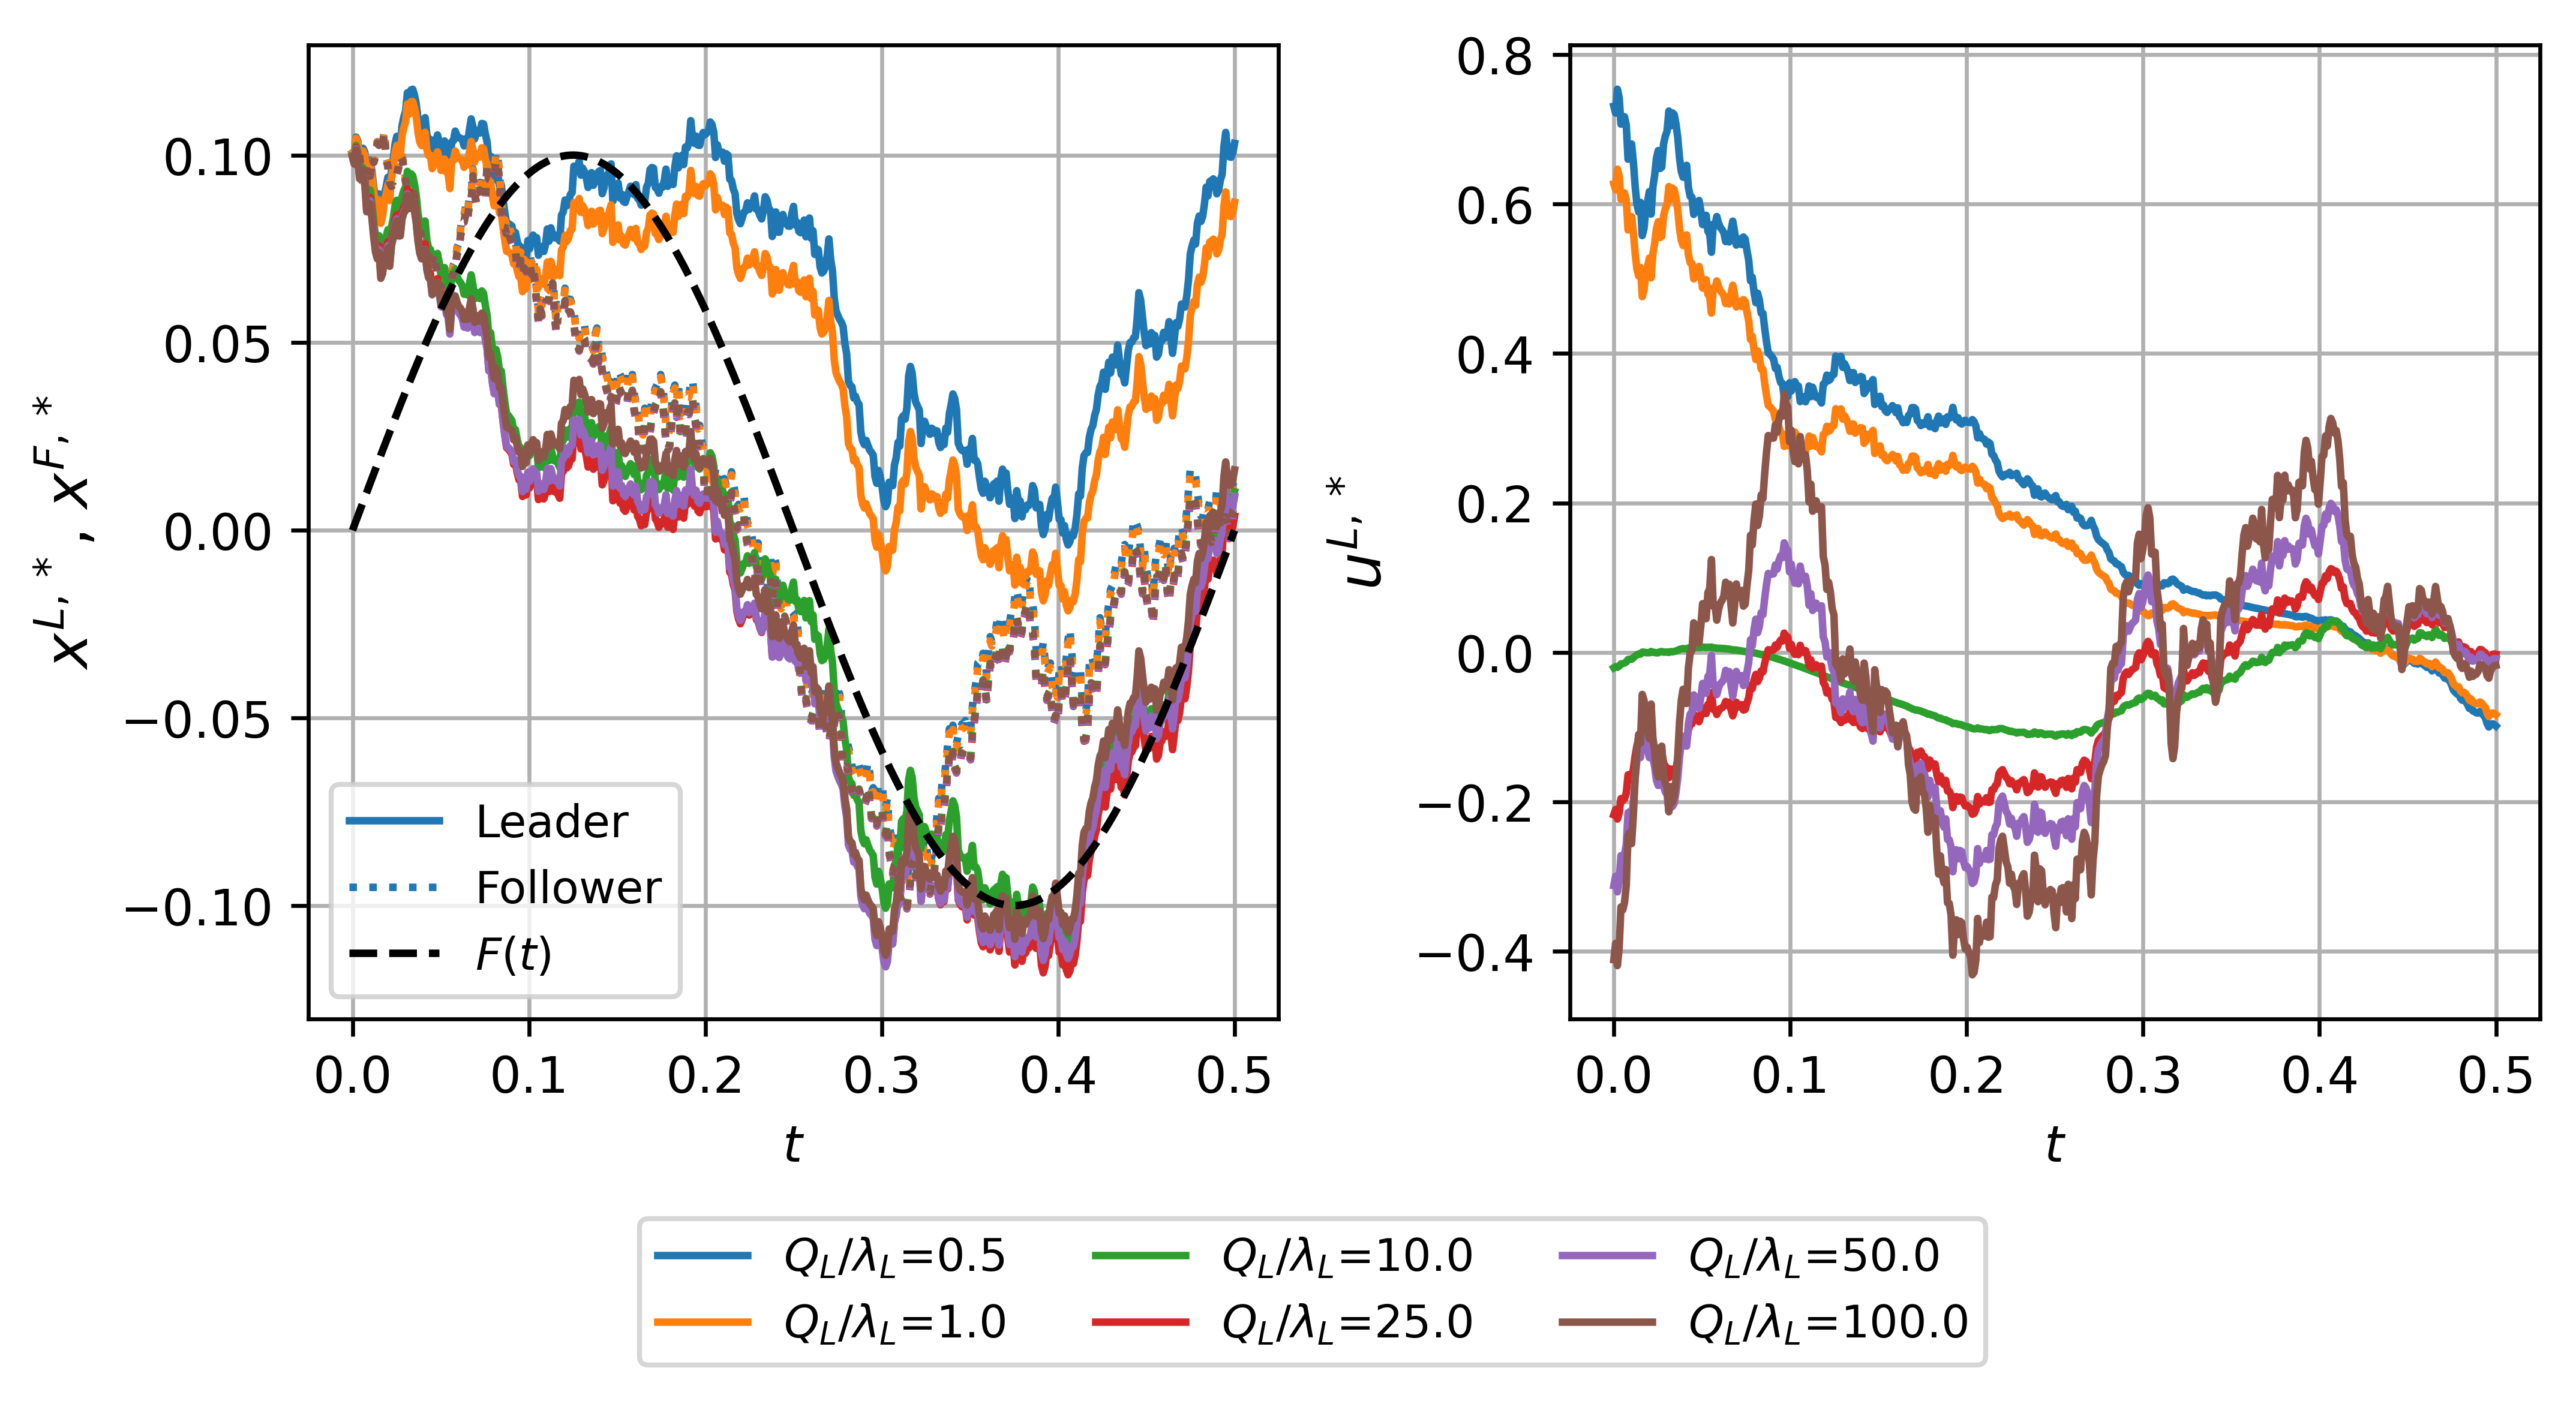

[(0.5, 0.14611053316689834), (1.0, 0.11989870070356737), (10.0, 0.015331827419408478), (25.0, 0.003868348710302499), (50.0, 0.0021161767251735805), (100.0, 0.002126350150187175)]


In [15]:
# show tradeoff between primary and info tasks
def F(x):
    return 0.1 * torch.sin(2*np.pi * x / params.T)

N = 500
T = 0.5

params = SystemParams()
params.A_L, params.A_F = -1.0, -1.0
params.B_L, params.B_F = 1.0, 1.0
params.sig_L, params.sig_F = 0.1, 0.1
params.M_true = 1.0
params.lamb_F = 1.0
params.lamb_L = 1.0
params.Q_L_T = 1.0
params.Q_L, params.Q_F = None, 1.0
params.R_L, params.R_F = 1.0, 1.0
params.X_L_0, params.X_F_0 = 0.1, 0.1
params.T, params.N = T, N
params.device = device
params.time_grid = torch.linspace(0, params.T, params.N + 1, device=params.device)
params.dt = params.T / params.N

fig = plt.figure(figsize=(8, 4.5), dpi=600)
gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 0.28], wspace=0.3, hspace=0.00)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax_leg = fig.add_subplot(gs[1, :])
ax_leg.set_axis_off()

Fisher_info_list = []
ql_list = [0.5, 1., 10., 25., 50., 100.]
for i, Q_L in enumerate(ql_list):
    params.Q_L = Q_L
    leader_analytic = LeaderLBSolver(params, F)
    X_L, U_L = leader_analytic.simulate(batch=1, seed=2)
    X_F, U_F = simulate_follower(X_L, params, batch=1, seed=3)
    Fisher_info = estimate_I_batch(leader_analytic.simulate(batch=10000, seed=2)[0], params=params)
    Fisher_info_list.append((params.Q_L/ params.lamb_L, Fisher_info))
    if i == 0:
        ax1.plot(torch.linspace(0, params.T, X_L.shape[1]), X_L[0, :].cpu().numpy(), label='Leader', color=f'C{i}', linestyle='-')
        ax1.plot(torch.linspace(0, params.T, X_F.shape[1]), X_F[0, :].cpu().numpy(), label='Follower', color=f'C{i}', linestyle=':')
    else:
        ax1.plot(torch.linspace(0, params.T, X_L.shape[1]), X_L[0, :].cpu().numpy(), color=f'C{i}', linestyle='-')
        ax1.plot(torch.linspace(0,params.T, X_F.shape[1]), X_F[0, :].cpu().numpy(), color=f'C{i}', linestyle=':')
    ax2.plot(torch.linspace(0, params.T, U_L.shape[1]), U_L[0, :].cpu().numpy(), color=f'C{i}')

ax1.plot(torch.linspace(0, params.T, X_L.shape[1]), F(torch.linspace(0, params.T, X_L.shape[1])).cpu().numpy(), 'k--', label='$F(t)$')
ax1.set_xlabel('$t$')
ax1.set_ylabel('$x^{L,*}$, $x^{F,*}$', fontsize=12)
ax1.legend(fontsize=9, loc='lower left')
ax1.grid(True)

ax2.set_xlabel('$t$')
ax2.set_ylabel('$u^{L,*}$', fontsize=12)
ax2.grid(True)

for i, Q_L in enumerate(ql_list):
    ax_leg.plot([], [], color=f'C{i}', label=r'$Q_L/\lambda_L$'+f'={Q_L}')
leg = ax_leg.legend(loc='center', ncol=3, frameon=True, fontsize=9, bbox_to_anchor=(0.45, 0.0))

plt.tight_layout()
plt.show()

print(Fisher_info_list)


/var/folders/bs/pjtn_x6x0vlg303wglbxqthm0000gn/T/ipykernel_13889/3617140130.py:80: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  exact_net.load_state_dict(torch.load(os.getc

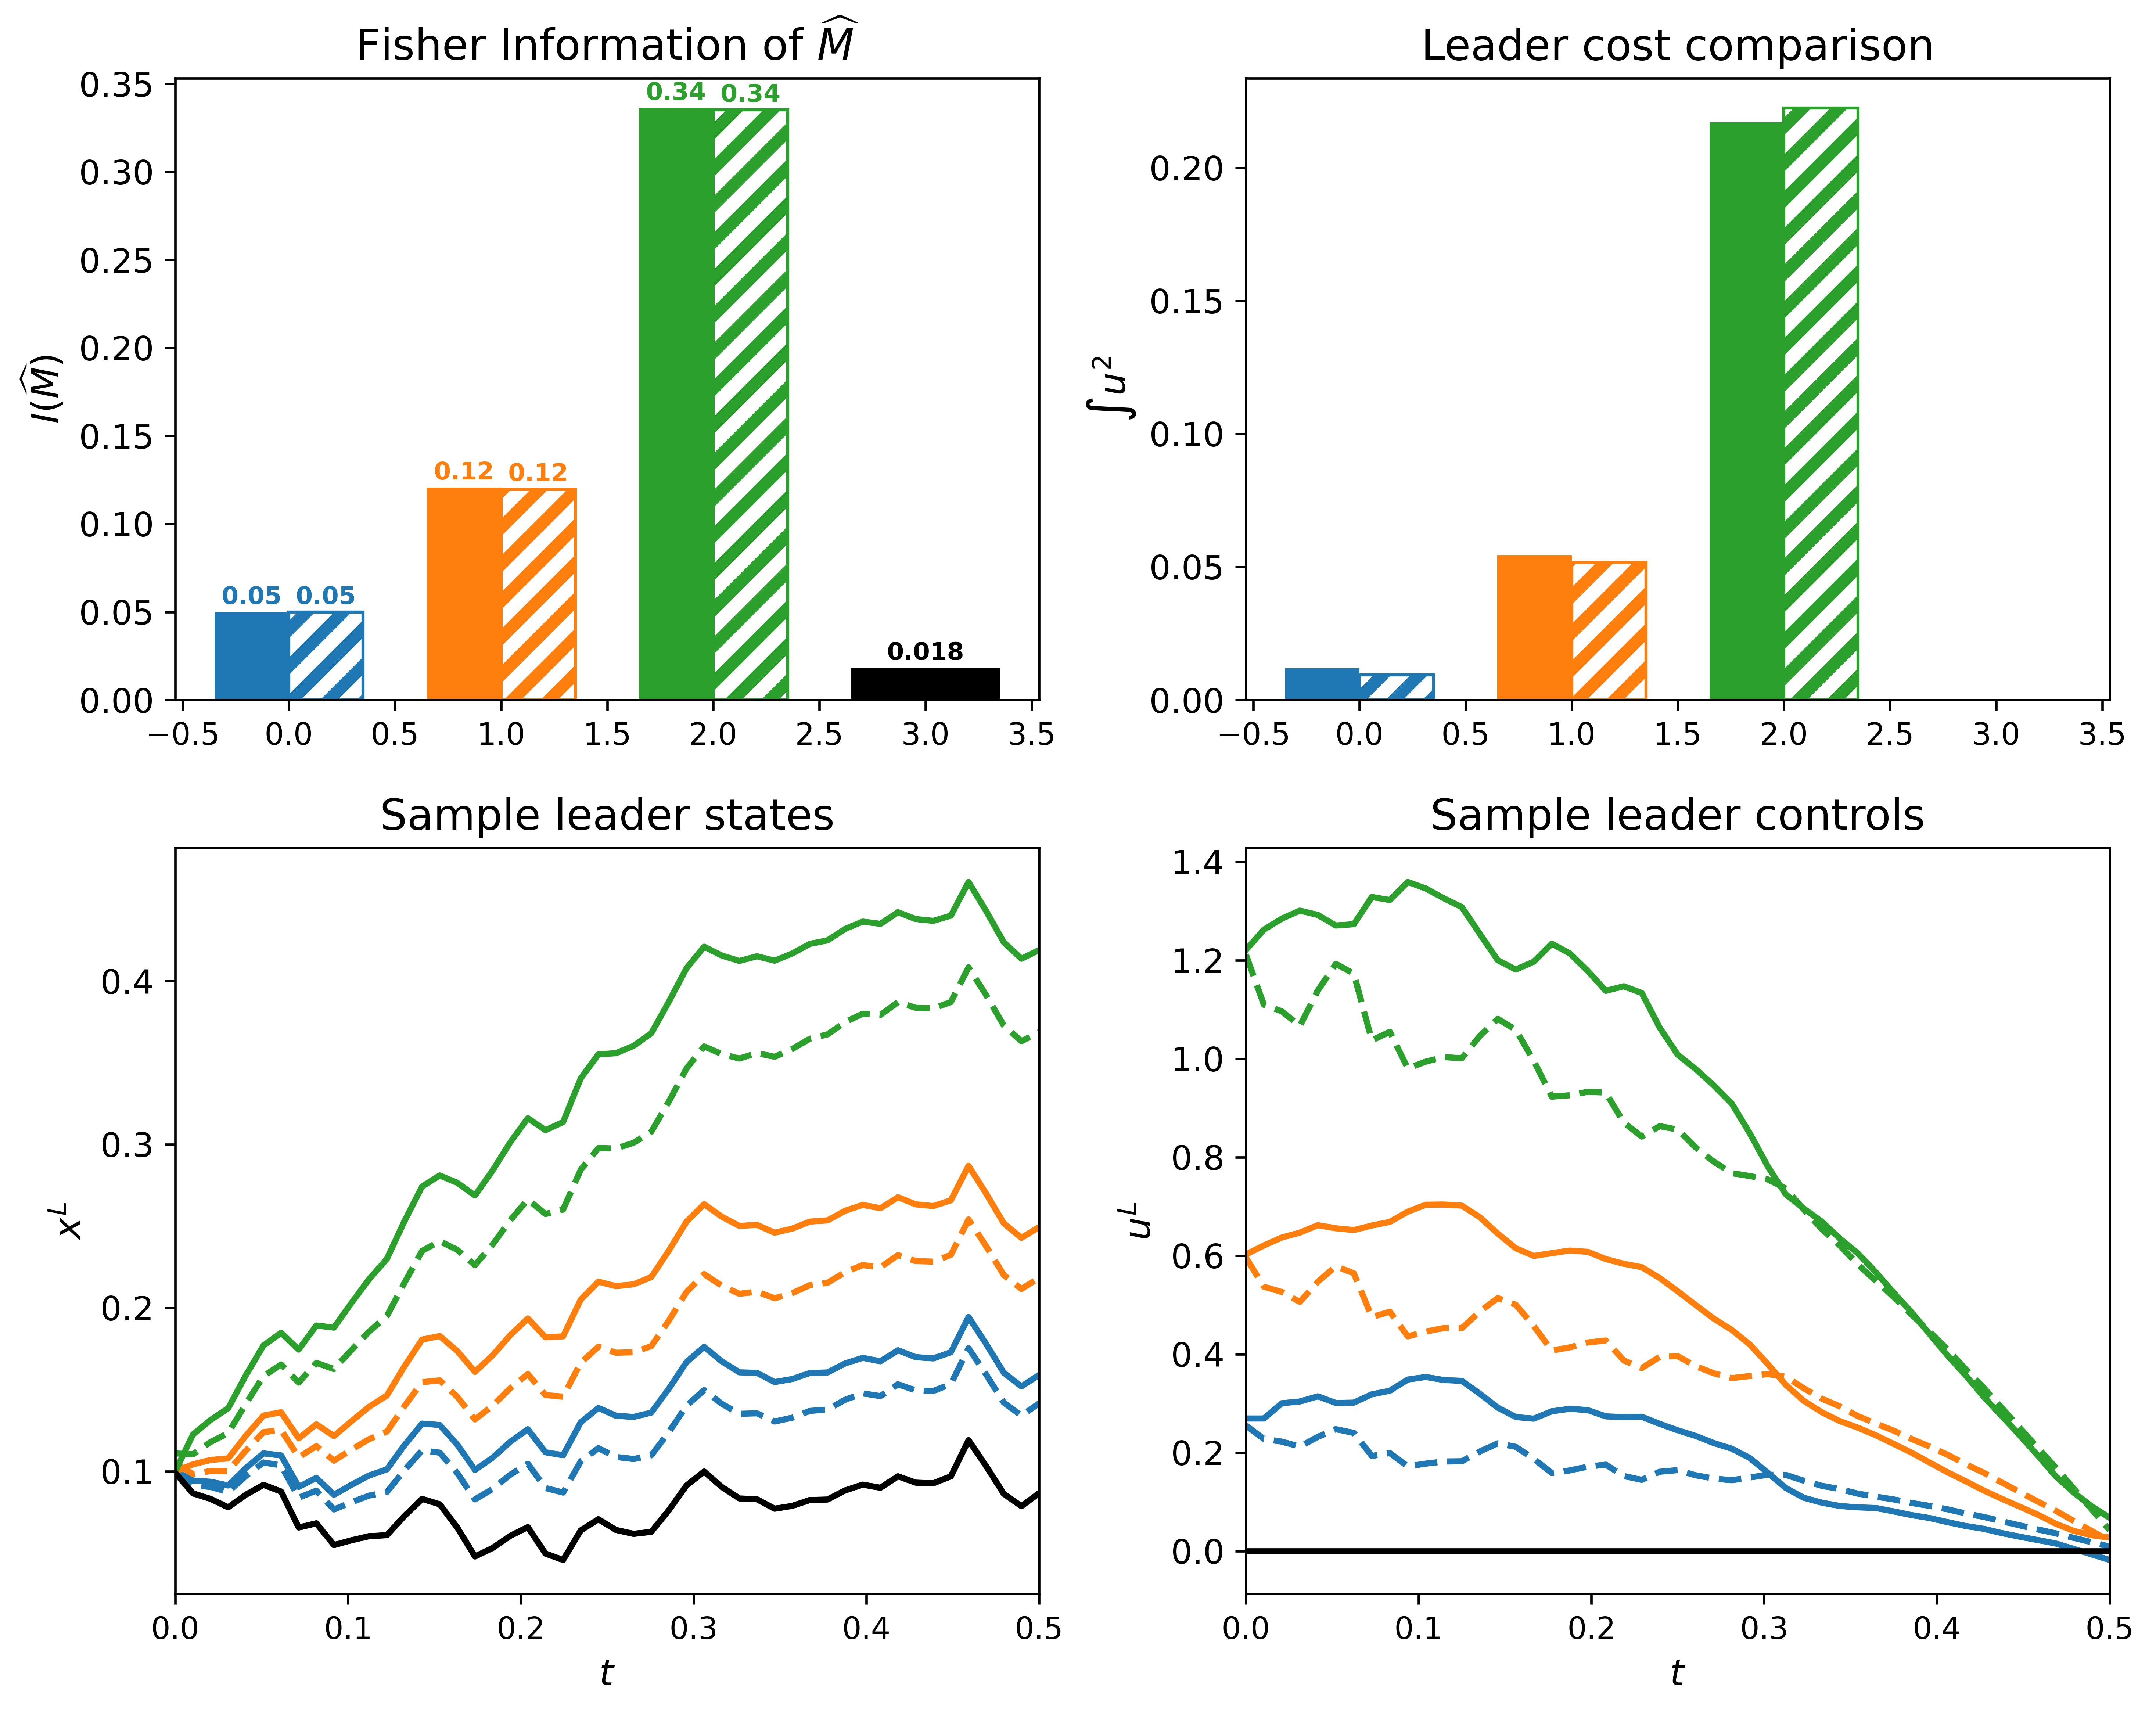

In [ ]:
# --- MATCH COLORS ACROSS ALL PLOTS; FIM = DASHED (states, controls, bars) ---

import numpy as np
import torch
import matplotlib.pyplot as plt
import os
from matplotlib.lines import Line2D


def F(x):
    return 0 * torch.ones_like(x)

T, N = 0.5, 50

lamb_pairs = [
    (1e-7, .46),
    (1e-6, .697),
    (1e-5, .873),
]
var_weight_files = [
    (1e-7, "/runs/pensions_characterize/final_weights.pt"),
    (1e-6, "/runs/prisoners_troopers/final_weights.pt"),
    (1e-5, "/runs/playground_amir/final_weights.pt"),
]
combined_pairs = [(weight_file, lamb_L_exact, lamb_L_LB) for (lamb_L_exact, lamb_L_LB), (_, weight_file) in zip(lamb_pairs, var_weight_files)]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

lambda_exact_vals               = []
lambda_lb_vals                  = []
estI_exact_vals, estI_lb_vals   = [], []
exact_cost_vals, lb_cost_vals   = [], []

# Figure layout: 2 rows x 2 columns
fig = plt.figure(figsize=(10, 8), dpi=600)

plt.rcParams.update({
    "font.size": 14,
    "font.weight": 550,
    "axes.titleweight": 550,
    "axes.labelweight": 550,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "lines.linewidth": 2.0,
    "lines.markersize": 5,
    "hatch.linewidth": 4.0
})

gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2])

# Top row: bars
ax_estI  = fig.add_subplot(gs[0, 0])
ax_cost  = fig.add_subplot(gs[0, 1])

# Bottom row: left = states, right = controls (share x for perfect alignment)
ax_state = fig.add_subplot(gs[1, 0])
ax_ctrl  = fig.add_subplot(gs[1, 1], sharex=ax_state)

for i, (weight_file, lamb_L_exact, lamb_L_LB) in enumerate(combined_pairs):
    color_i = f"C{i}"

    params_exact = SystemParams()
    params_exact.A_L, params_exact.A_F = -1.0, -1.0
    params_exact.B_L, params_exact.B_F = 1.0, 1.0
    params_exact.sig_L, params_exact.sig_F = 0.1, 0.1
    params_exact.M_true, params_exact.lamb_F = 1.0, 1.0
    params_exact.lamb_L = lamb_L_exact
    params_exact.Q_L_T, params_exact.Q_L, params_exact.Q_F = 0.0, 0.0, 1.0
    params_exact.R_L, params_exact.R_F = 1.0, 1.0
    params_exact.X_L_0, params_exact.X_F_0 = 0.1, 0.1
    params_exact.T, params_exact.N = T, N
    params_exact.device = device
    params_exact.time_grid = torch.linspace(0, T, N + 1, device=device)
    params_exact.dt = T / N

    exact_net = DeepLSTMController()
    exact_net.load_state_dict(torch.load(os.getcwd() + weight_file, map_location=device))
    exact_net.to(device)

    X_L_exact, U_L_exact = simulate_leader(make_nn_policy(exact_net, params_exact), params_exact, batch=10000, seed=0)
    est_I = estimate_I_batch(X_L_exact, params_exact)

    params_LB = SystemParams()
    for attr in vars(params_exact):
        setattr(params_LB, attr, getattr(params_exact, attr))
    params_LB.lamb_L = lamb_L_LB

    leader_lb = LeaderLBSolver(params_LB, F)
    X_L_lb, U_L_lb = leader_lb.simulate(batch=10000, seed=0)
    est_I_lb = estimate_I_batch(X_L_lb, params_LB)

    exact_cost = (1/2)*int_trapz(U_L_exact**2, params_exact.dt).mean()
    lb_cost    = (1/2)*int_trapz(U_L_lb**2, params_LB.dt).mean()

    # store scalars for bar plots
    lambda_exact_vals.append(float(lamb_L_exact))
    lambda_lb_vals.append(float(lamb_L_LB))
    estI_exact_vals.append(float(est_I))
    estI_lb_vals.append(float(est_I_lb))
    exact_cost_vals.append(float(exact_cost))
    lb_cost_vals.append(float(lb_cost))

    # time grids
    t_state_exact = torch.linspace(0, params_exact.T, X_L_exact[0].shape[0]).cpu().numpy()
    t_ctrl_exact  = torch.linspace(0, params_exact.T, U_L_exact[0].shape[0]).cpu().numpy()
    t_state_lb    = torch.linspace(0, params_LB.T,    X_L_lb[0].shape[0]).cpu().numpy()
    t_ctrl_lb     = torch.linspace(0, params_LB.T,    U_L_lb[0].shape[0]).cpu().numpy()

    # STATES: VarMin solid, FIM dashed — SAME COLOR
    ax_state.plot(t_state_exact, X_L_exact[0].detach().cpu().numpy(),
                  label=f'Var Min λ={lamb_L_exact}', color=color_i, linestyle='-')
    ax_state.plot(t_state_lb,    X_L_lb[0].detach().cpu().numpy(),
                  label=f'FIM λ={lamb_L_LB}',        color=color_i, linestyle='--')

    # CONTROLS: VarMin solid, FIM dashed — SAME COLOR
    ax_ctrl.plot(t_ctrl_exact, U_L_exact[0].detach().cpu().numpy(),
                 label=f'Var Min λ={lamb_L_exact}', color=color_i, linestyle='-')
    ax_ctrl.plot(t_ctrl_lb,    U_L_lb[0].detach().cpu().numpy(),
                 label=f'FIM λ={lamb_L_LB}',        color=color_i, linestyle='--')

# Baseline (λ=0)
params_baseline = SystemParams()
params_baseline.A_L, params_baseline.A_F = -1.0, -1.0
params_baseline.B_L, params_baseline.B_F = 1.0, 1.0
params_baseline.sig_L, params_baseline.sig_F = 0.1, 0.1
params_baseline.M_true, params_baseline.lamb_F = 1.0, 1.0
params_baseline.lamb_L = 0.0
params_baseline.Q_L_T, params_baseline.Q_L, params_baseline.Q_F = 0.0, 0.0, 1.0
params_baseline.R_L, params_baseline.R_F = 1.0, 1.0
params_baseline.X_L_0, params_baseline.X_F_0 = 0.1, 0.1
params_baseline.T, params_baseline.N = T, N
params_baseline.device = device
params_baseline.time_grid = torch.linspace(0, T, N + 1, device=device)
params_baseline.dt = T / N

baseline = LeaderLBSolver(params_baseline, F)
X_L_baseline, U_L_baseline = baseline.simulate(batch=10000, seed=0)
estI_baseline = float(estimate_I_batch(X_L_baseline, params_baseline))
baseline_cost = float(((1/2)*int_trapz(U_L_baseline**2, params_baseline.dt)).mean())

# baseline lines
t_state_base = torch.linspace(0, params_baseline.T, X_L_baseline[0].shape[0]).cpu().numpy()
t_ctrl_base  = torch.linspace(0, params_baseline.T, U_L_baseline[0].shape[0]).cpu().numpy()
ax_state.plot(t_state_base, 
              X_L_baseline[0].detach().cpu().numpy(), 
              label='Baseline λ=0.0', 
              color='k', 
              linestyle='-'
              )
ax_ctrl .plot(t_ctrl_base,  
              U_L_baseline[0].detach().cpu().numpy(), 
              label='Baseline λ=0.0', 
              color='k', 
              linestyle='-'
              )

# append baseline to arrays for bar plots
lambda_exact_vals.append(0.0)
lambda_lb_vals.append(0.0)
estI_exact_vals.append(estI_baseline)
estI_lb_vals.append(estI_baseline)
exact_cost_vals.append(baseline_cost)
lb_cost_vals.append(baseline_cost)

# ---- BAR PLOTS: draw bar-by-bar so each pair shares color; FIM dashed edges ----
x = np.arange(len(lambda_exact_vals))
width = 0.35
big_width = 2 * width
pair_count = len(lambda_exact_vals) - 1
base_idx = pair_count

# Estimated I
for i in range(pair_count):
    color_i = f"C{i}"
    # Var Min (solid edge), FIM (dashed edge) — both same facecolor
    bar_var = ax_estI.bar(i - width/2, 
                estI_exact_vals[i], 
                width,
                facecolor=color_i,
                # label=r'$\hat I_{\mathrm{VarMin}}$' if i == 0 else None
                )
    ax_estI.bar_label(bar_var, 
                      labels=[f"{estI_exact_vals[i]:.2g}"],
                      label_type='edge', 
                      padding=1,
                      fontsize=8, 
                      color=color_i,
                      fontweight='semibold'
    )
    bar_fim = ax_estI.bar(i + width/2, 
                estI_lb_vals[i], 
                width,
                facecolor='none',
                edgecolor=color_i,
                hatch = '//',
                # label=r'$\hat I_{\mathrm{FIM}}$' if i == 0 else None,
                )
    ax_estI.bar_label(bar_fim, 
                      labels=[f"{estI_lb_vals[i]:.2g}"],
                      label_type='edge', 
                      padding=1, 
                      fontsize=8,
                      color=color_i,
                      fontweight='semibold'
    )

# Baseline bar (centered, black)
bar_base_var = ax_estI.bar(base_idx, 
                           estI_baseline, 
                           big_width,
                           facecolor='k',
                           label=r'Baseline $\lambda=0$')
ax_estI.bar_label(bar_base_var, 
                  labels=[f"{estI_baseline:.2g}"],
                    label_type='edge',
                    padding=1,
                    fontsize=8,
                    color='k',
                    fontweight='semibold'
                    )


ax_estI.set_ylabel(r'$I(\widehat{M})$')
ax_estI.set_title(r'Fisher Information of $\widehat{M}$')

# Cost
for i in range(pair_count):
    color_i = f"C{i}"
    ax_cost.bar(i - width/2, exact_cost_vals[i], width,
                facecolor=color_i, 
                label='Var Min' if i == 0 else None
                )
    ax_cost.bar(i + width/2, lb_cost_vals[i], width,
                facecolor='none', 
                edgecolor=color_i, 
                hatch = '//',
                label='FIM' if i == 0 else None
                )

ax_cost.bar(base_idx, baseline_cost, big_width,
            facecolor='k',
            label=r'Baseline $\lambda=0$'
            )

ax_cost.set_ylabel('$\int u^2$')
ax_cost.set_title('Leader cost comparison')

# Common x-axis labels
pair_labels = [
    rf"($\lambda^{{\mathrm{{VarMin}}}}_L$={v:.2g}, $\lambda^{{\mathrm{{FIM}}}}_L$={u:.2g})"
    for v, u in zip(lambda_exact_vals[:pair_count], lambda_lb_vals[:pair_count])
]
pair_labels.append(r'Baseline $\lambda=0$')

# for ax in (ax_estI, ax_cost):
#     ax.set_xticks(x)
#     ax.set_xticklabels(pair_labels, rotation=25, ha='right')
#     h, l = ax.get_legend_handles_labels()
#     uniq = dict(zip(l, h))
#     ax.legend(uniq.values(), uniq.keys(), loc='best')

# Bottom axes cosmetics
ax_state.set_xlim(0, T)
ax_ctrl.set_xlim(0, T)

ax_state.set_xlabel('$t$')
ax_state.set_ylabel('$x^L$')
ax_state.set_title('Sample leader states')
# ax_state.legend(ncol=2, loc='upper right')

ax_ctrl.set_xlabel('$t$')
ax_ctrl.set_ylabel('$u^L$')
ax_ctrl.set_title('Sample leader controls')
# ax_ctrl.legend(ncol=2, loc='upper right')

plt.tight_layout()
plt.show()


/var/folders/bs/pjtn_x6x0vlg303wglbxqthm0000gn/T/ipykernel_7169/1564622432.py:78: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  exact_net.load_state_dict(torch.load(os.getcw

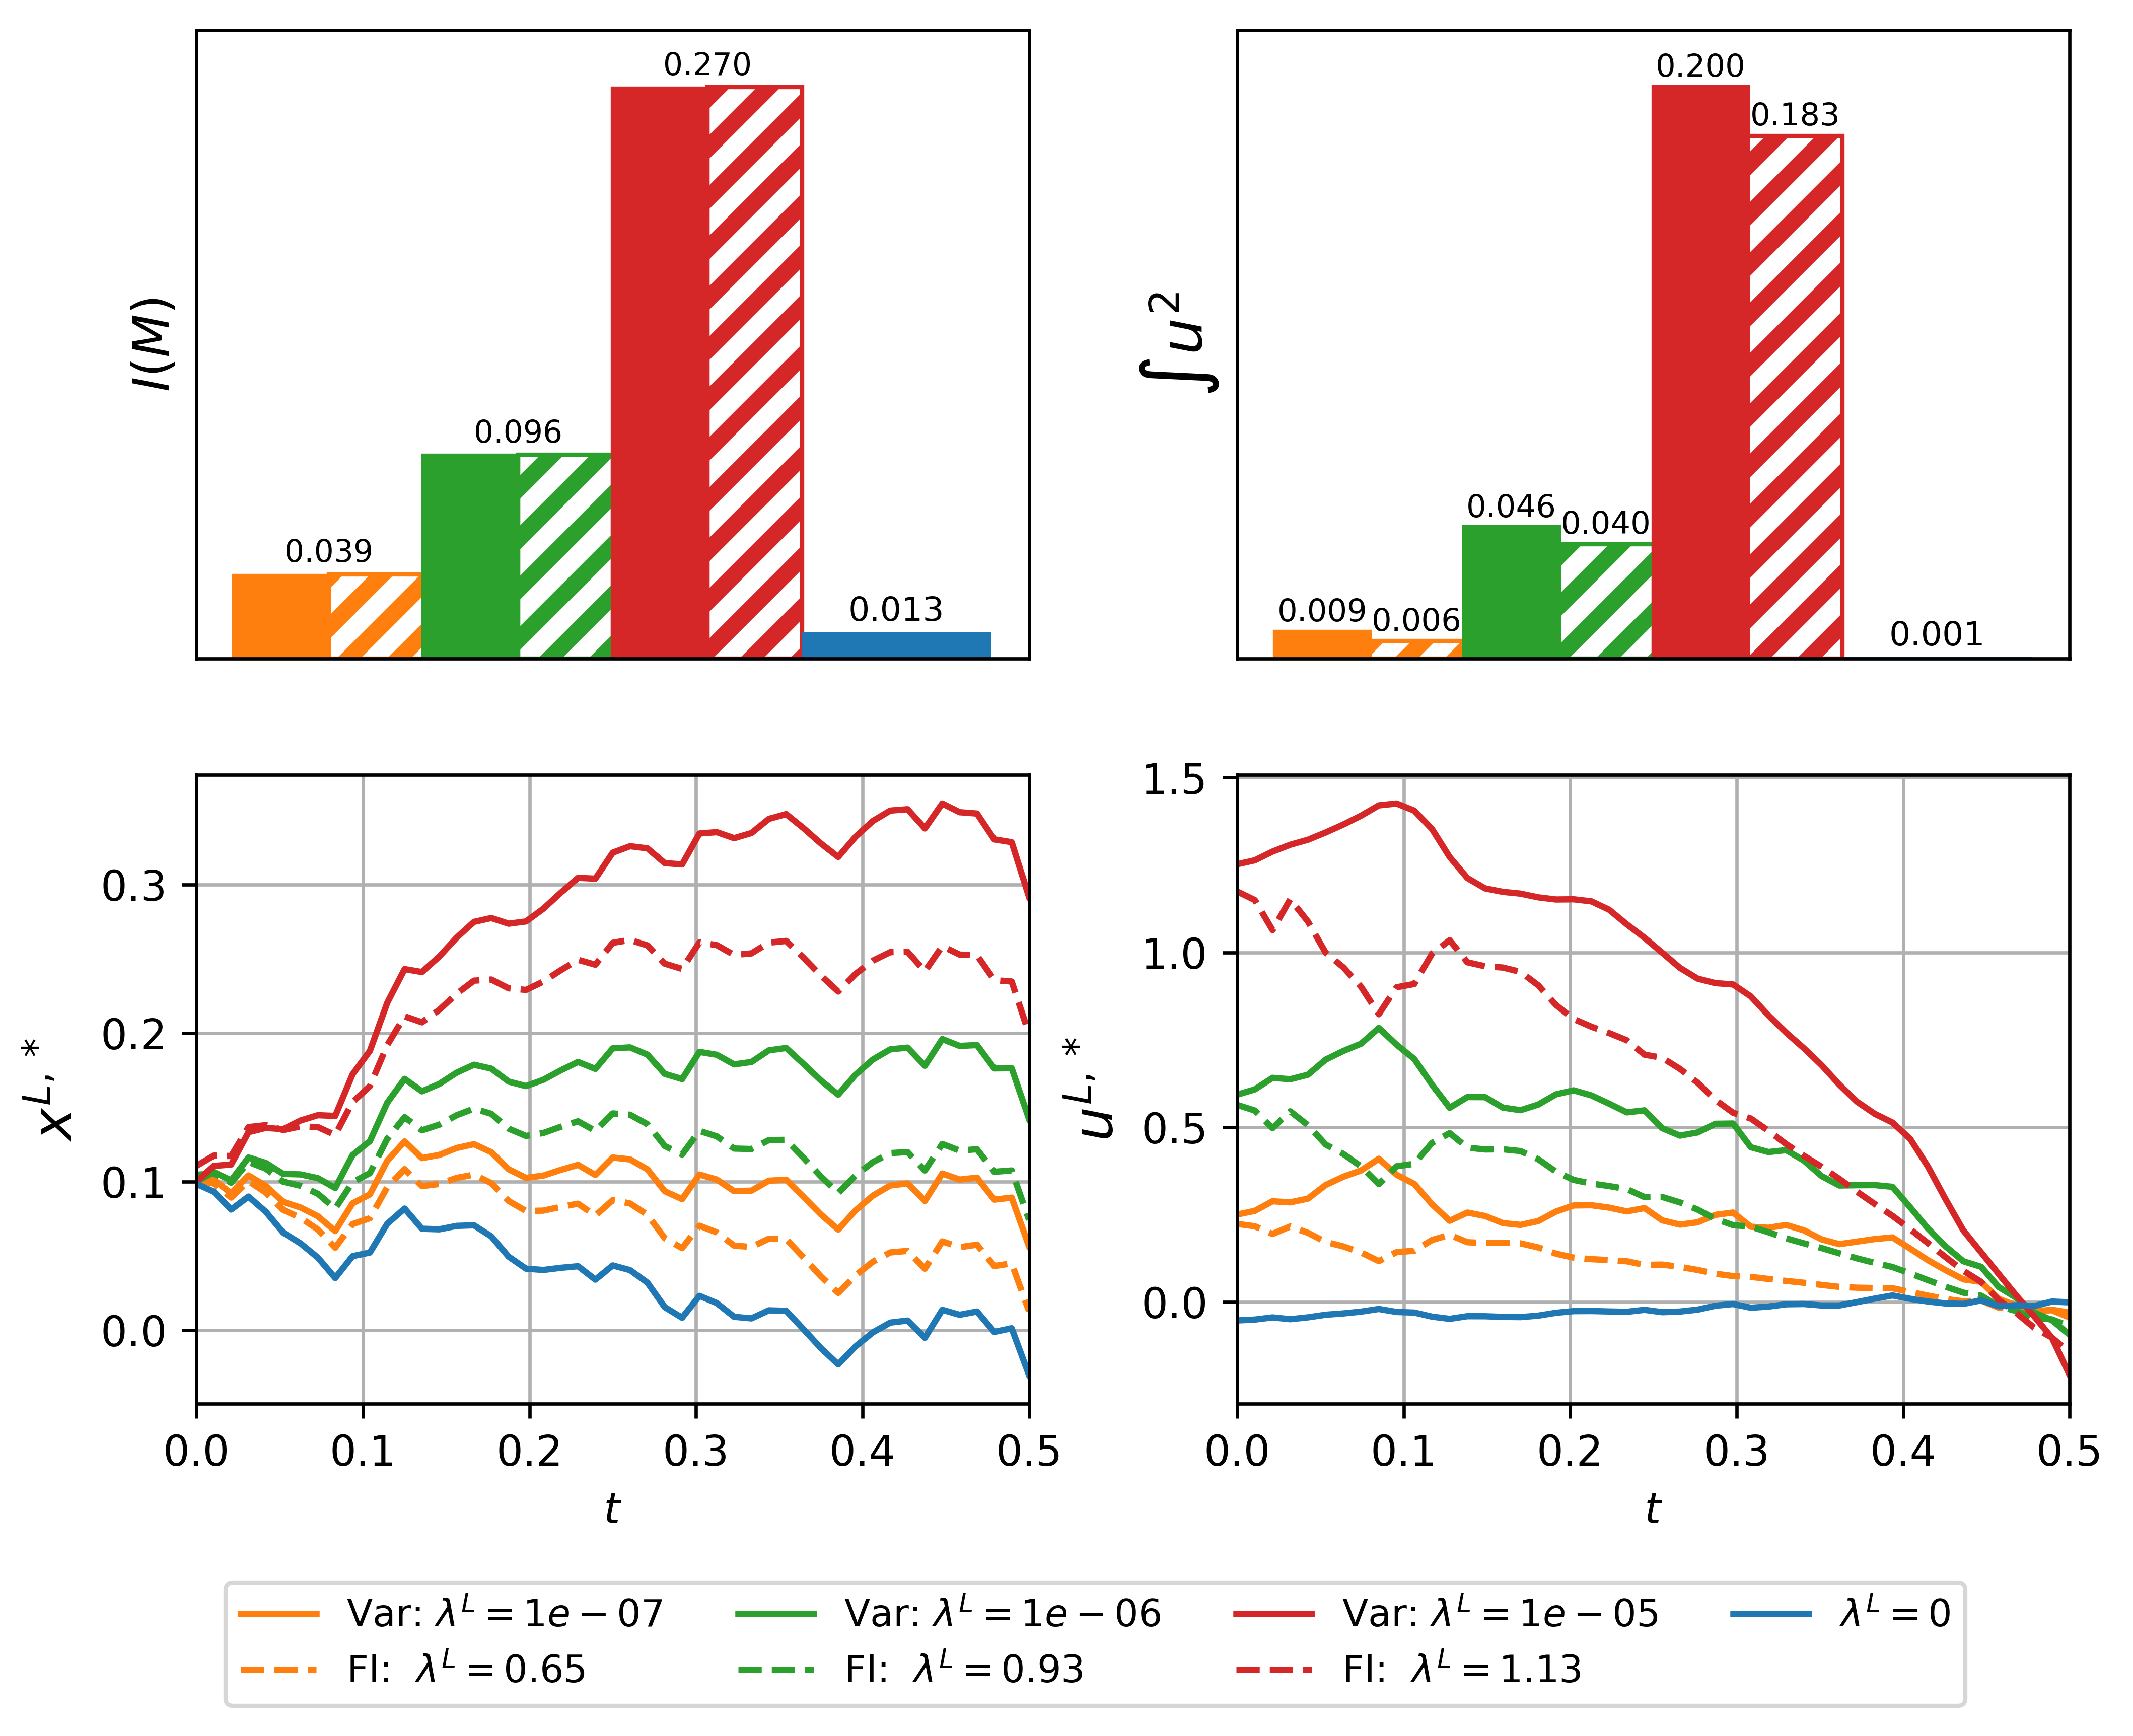

In [16]:
# --- MATCH COLORS ACROSS ALL PLOTS; FIM = DASHED (states, controls, bars) ---

import numpy as np
import torch
import matplotlib.pyplot as plt
import os
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

def F(x):
    return 0 * torch.ones_like(x)

T, N = 0.5, 50

lamb_pairs = [
    (1e-7, .65),
    (1e-6, .93),
    (1e-5, 1.1335),
]
var_weight_files = [
    (1e-7, "/runs/soothing_residences/loss_4.875e-02_upd_10153.pt"),
    (1e-6, "/runs/remained_resting/loss_1.762e-01_upd_15000.pt"),
    (1e-5, "/runs/tryin_exceed/loss_6.298e-01_upd_15000.pt"),
    # (1e-7, "/runs/pensions_characterize/final_weights.pt"),
    # (1e-6, "/runs/prisoners_troopers/final_weights.pt"),
    # (1e-5, "/runs/playground_amir/final_weights.pt"),
]
combined_pairs = [(weight_file, lamb_L_exact, lamb_L_LB)
                  for (lamb_L_exact, lamb_L_LB), (_, weight_file)
                  in zip(lamb_pairs, var_weight_files)]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

lambda_exact_vals               = []
lambda_lb_vals                  = []
estI_exact_vals, estI_lb_vals   = [], []
exact_cost_vals, lb_cost_vals   = [], []

# ---------------- LAYOUT ----------------
# 3-row GridSpec: (row 0) 2 plots, (row 1) 2 plots, (row 2) legend spanning both columns
fig = plt.figure(figsize=(8, 7), dpi=600)
gs = fig.add_gridspec(
    3, 2,
    height_ratios=[1.0, 1.0, 0.22],
    hspace=0.25, wspace=0.25
)

# Row 0
ax_estI = fig.add_subplot(gs[0, 0])
ax_cost = fig.add_subplot(gs[0, 1])

# Row 1
ax_state = fig.add_subplot(gs[1, 0])
ax_ctrl  = fig.add_subplot(gs[1, 1], sharex=ax_state)

# Row 2 (legend-only axis)
ax_legend = fig.add_subplot(gs[2, :])
ax_legend.set_axis_off()

for i, (weight_file, lamb_L_exact, lamb_L_LB) in enumerate(combined_pairs):
    color_i = f"C{i+1}"

    params_exact = SystemParams()
    params_exact.A_L, params_exact.A_F = -1.0, -1.0
    params_exact.B_L, params_exact.B_F = 1.0, 1.0
    params_exact.sig_L, params_exact.sig_F = 0.1, 0.1
    params_exact.M_true, params_exact.lamb_F = 1.0, 1.0
    params_exact.lamb_L = lamb_L_exact
    params_exact.Q_L_T, params_exact.Q_L, params_exact.Q_F = 1.0, 1.0, 1.0
    params_exact.R_L, params_exact.R_F = 1.0, 1.0
    params_exact.X_L_0, params_exact.X_F_0 = 0.1, 0.1
    params_exact.T, params_exact.N = T, N
    params_exact.device = device
    params_exact.time_grid = torch.linspace(0, T, N + 1, device=device)
    params_exact.dt = T / N

    exact_net = DeepLSTMController(num_layers=2)
    exact_net.load_state_dict(torch.load(os.getcwd() + weight_file, map_location=device))
    exact_net.to(device)

    X_L_exact, U_L_exact = simulate_leader(make_nn_policy(exact_net, params_exact), params_exact, batch=10000, seed=0)
    est_I = estimate_I_batch(X_L_exact, params_exact)

    params_LB = SystemParams()
    for attr in vars(params_exact):
        setattr(params_LB, attr, getattr(params_exact, attr))
    params_LB.lamb_L = lamb_L_LB

    leader_lb = LeaderLBSolver(params_LB, F)
    X_L_lb, U_L_lb = leader_lb.simulate(batch=10000, seed=0)
    est_I_lb = estimate_I_batch(X_L_lb, params_LB)

    exact_cost = (1/2)*int_trapz(U_L_exact**2, params_exact.dt).mean()
    lb_cost    = (1/2)*int_trapz(U_L_lb**2, params_LB.dt).mean()

    # store scalars for bar plots
    lambda_exact_vals.append(float(lamb_L_exact))
    lambda_lb_vals.append(float(lamb_L_LB))
    estI_exact_vals.append(float(est_I))
    estI_lb_vals.append(float(est_I_lb))
    exact_cost_vals.append(float(exact_cost))
    lb_cost_vals.append(float(lb_cost))

    # time grids
    t_state_exact = torch.linspace(0, params_exact.T, X_L_exact[0].shape[0]).cpu().numpy()
    t_ctrl_exact  = torch.linspace(0, params_exact.T, U_L_exact[0].shape[0]).cpu().numpy()
    t_state_lb    = torch.linspace(0, params_LB.T,    X_L_lb[0].shape[0]).cpu().numpy()
    t_ctrl_lb     = torch.linspace(0, params_LB.T,    U_L_lb[0].shape[0]).cpu().numpy()

    # STATES: VarMin solid, FIM dashed — SAME COLOR
    ax_state.plot(t_state_exact, X_L_exact[0].detach().cpu().numpy(),
                  label=f'Var Min λ={lamb_L_exact}', color=color_i, linestyle='-')
    ax_state.plot(t_state_lb,    X_L_lb[0].detach().cpu().numpy(),
                  label=f'FIM λ={lamb_L_LB}',        color=color_i, linestyle='--')

    # CONTROLS: VarMin solid, FIM dashed — SAME COLOR
    ax_ctrl.plot(t_ctrl_exact, U_L_exact[0].detach().cpu().numpy(),
                 label=f'Var Min λ={lamb_L_exact}', color=color_i, linestyle='-')
    ax_ctrl.plot(t_ctrl_lb,    U_L_lb[0].detach().cpu().numpy(),
                 label=f'FIM λ={lamb_L_LB}',        color=color_i, linestyle='--')

# Baseline (λ=0)
params_baseline = SystemParams()
params_baseline.A_L, params_baseline.A_F = -1.0, -1.0
params_baseline.B_L, params_baseline.B_F = 1.0, 1.0
params_baseline.sig_L, params_baseline.sig_F = 0.1, 0.1
params_baseline.M_true, params_baseline.lamb_F = 1.0, 1.0
params_baseline.lamb_L = 0.0
params_baseline.Q_L_T, params_baseline.Q_L, params_baseline.Q_F = 1.0, 1.0, 1.0
params_baseline.R_L, params_baseline.R_F = 1.0, 1.0
params_baseline.X_L_0, params_baseline.X_F_0 = 0.1, 0.1
params_baseline.T, params_baseline.N = T, N
params_baseline.device = device
params_baseline.time_grid = torch.linspace(0, T, N + 1, device=device)
params_baseline.dt = T / N

baseline = LeaderLBSolver(params_baseline, F)
X_L_baseline, U_L_baseline = baseline.simulate(batch=10000, seed=0)
estI_baseline = float(estimate_I_batch(X_L_baseline, params_baseline))
baseline_cost = float(((1/2)*int_trapz(U_L_baseline**2, params_baseline.dt)).mean())

# baseline lines
t_state_base = torch.linspace(0, params_baseline.T, X_L_baseline[0].shape[0]).cpu().numpy()
t_ctrl_base  = torch.linspace(0, params_baseline.T, U_L_baseline[0].shape[0]).cpu().numpy()
ax_state.plot(t_state_base,
              X_L_baseline[0].detach().cpu().numpy(),
              label='Baseline λ=0.0',
              color=f"C{0}",
              linestyle='-')
ax_ctrl .plot(t_ctrl_base,
              U_L_baseline[0].detach().cpu().numpy(),
              label='Baseline λ=0.0',
              color=f"C{0}",
              linestyle='-')

# append baseline to arrays for bar plots
lambda_exact_vals.append(0.0)
lambda_lb_vals.append(0.0)
estI_exact_vals.append(estI_baseline)
estI_lb_vals.append(estI_baseline)
exact_cost_vals.append(baseline_cost)
lb_cost_vals.append(baseline_cost)

# ---- BAR PLOTS: draw bar-by-bar so each pair shares color; FIM dashed edges ----
x = np.arange(len(lambda_exact_vals))
width = 0.5
big_width = 2 * width
pair_count = len(lambda_exact_vals) - 1
base_idx = pair_count

# Estimated I
for i in range(pair_count):
    color_i = f"C{i+1}"
    # Var Min (solid edge), FIM (dashed/hatch edge) — both same facecolor
    bar_var = ax_estI.bar(i - width/2,
                estI_exact_vals[i],
                width,
                facecolor=color_i,
                edgecolor=color_i)
    # ax_estI.bar_label(bar_var,
    #                   labels=[f"{estI_exact_vals[i]:.3f}"],
    #                   label_type='edge',
    #                   padding=1,
    #                   fontsize=7.5,
    #                   color=color_i,
    #                   fontweight=300, 
    # )
    bar_fim = ax_estI.bar(i + width/2,
                estI_lb_vals[i],
                width,
                facecolor='none',
                edgecolor=color_i,
                hatch='//',
                hatch_linewidth=4.0)
    # ax_estI.bar_label(bar_fim,
    #                   labels=[f"{estI_lb_vals[i]:.3f}"],
    #                   label_type='edge',
    #                   padding=1,
    #                   fontsize=7.5,
    #                   color=color_i,
    #                   fontweight=300)
    r1, r2 = bar_var[0], bar_fim[0]
    x1 = r1.get_x() + r1.get_width()/2
    x2 = r2.get_x() + r2.get_width()/2
    y1 = r1.get_height()
    y2 = r2.get_height()

    x_mid = 0.5 * (x1 + x2)
    y_mid = max(y1, y2) + 0.01
    # Optionally: y_mid = max(y1, y2) * 1.02  # to float just above both

    ax_estI.text(x_mid, y_mid,
                f"{estI_exact_vals[i]:.3f}",
                ha='center', va='center',
                fontsize=7.4,
                # color=color_i,
                linespacing=0.9)

# Baseline bar (centered, black)
bar_base_var = ax_estI.bar(base_idx,
                           estI_baseline,
                           big_width,
                           facecolor=f"C{0}",
                           label=r'Baseline $\lambda=0$')
ax_estI.bar_label(bar_base_var,
                  labels=[f"{estI_baseline:.3f}"],
                  label_type='edge',
                  padding=1,
                  fontsize=8,
                #   color=f"C{0}",
                  fontweight=400)

ax_estI.set_ylabel(r'$I(M)$', fontsize=12)

# Cost
for i in range(pair_count):
    color_i = f"C{i+1}"
    bar_var_cost = ax_cost.bar(i - width/2, exact_cost_vals[i], width,
                               facecolor=color_i, edgecolor=color_i,
                               label='Var Min' if i == 0 else None)
    ax_cost.bar_label(bar_var_cost,
                      labels=[f"{exact_cost_vals[i]:.3f}"],
                      label_type='edge',
                      padding=1,
                      fontsize=7.5,
                    #   color=color_i,
                      fontweight=400)
    bar_FI_cost = ax_cost.bar(i + width/2, lb_cost_vals[i], width,
                              facecolor='none', edgecolor=color_i, hatch='//', hatch_linewidth=4.0,
                              label='FIM' if i == 0 else None)
    ax_cost.bar_label(bar_FI_cost,
                      labels=[f"{lb_cost_vals[i]:.3f}"],
                      label_type='edge',
                      padding=1,
                      fontsize=7.5,
                    #   color=color_i,
                      fontweight=400)

bar_base_cost = ax_cost.bar(base_idx, baseline_cost, big_width,
                            facecolor=f"C{0}",
                            label=r'Baseline $\lambda=0$')
ax_cost.bar_label(bar_base_cost,
                  labels=[f"{baseline_cost:.3f}"],
                  label_type='edge',
                  padding=1,
                  fontsize=8,
                #   color=f"C{0}",
                  fontweight=400)

ax_cost.set_ylabel('$\\int u^2$', fontsize=14)

# Build legend in the bottom row axis (4 columns)
for i in range(len(lambda_exact_vals) - 1):
    color_i = f"C{i+1}"
    ax_legend.plot([], [], color=color_i, linestyle='-',  label=f'Var: $\lambda^L={lambda_exact_vals[i]}$')
    ax_legend.plot([], [], color=color_i, linestyle='--', label=f'FI:  $\lambda^L={lambda_lb_vals[i]:.2f}$')
ax_legend.plot([], [], color=f"C{0}", linestyle='-', label='$\\lambda^L=0$')
leg = ax_legend.legend(loc='center', ncol=4, frameon=True, fontsize=9, bbox_to_anchor=(.48, 0.1))

# Cosmetics
ax_estI.set_xticks([])
ax_estI.set_yticks([])
ax_cost.set_xticks([])
ax_cost.set_yticks([])
ax_estI.set_ylim(0, max(estI_exact_vals + estI_lb_vals) * 1.1)
ax_cost.set_ylim(0, max(exact_cost_vals + lb_cost_vals) * 1.1)

ax_state.set_xlim(0, T)
ax_ctrl.set_xlim(0, T)

ax_state.set_xlabel('$t$')
ax_state.set_ylabel('$x^{L,*}$', fontsize=13)
ax_state.grid(True)

ax_ctrl.set_xlabel('$t$')
ax_ctrl.set_ylabel('$u^{L,*}$', fontsize=13)
ax_ctrl.grid(True)

plt.tight_layout()
plt.show()
